## Requisitos del entorno

Ejecutar este notebook en un entorno con `pandas`, `numpy`, `scikit-learn`, `statsmodels`, `seaborn`, `matplotlib`, `plotly`, `openpyxl`, `joblib` y `gdown` previamente instalados.

> **Secuencia de ejecución CRISP-DM:**
> 1. `01_carga_datos.ipynb — Fase 1: Comprensión del negocio + Carga de datos`
> 2. `02_limpieza_variables.ipynb — Fase 2: Comprensión y preparación de datos`
> 3. `03_universo_analitico.ipynb — Fase 3: Preparación de datos (integración y variables económicas)`
> 4. `04_modelado.ipynb — Fase 4: Modelado (WLS + KMeans)`
> 5. `05_modelo_hibrido.ipynb — Fase 4b: Modelo Híbrido (residuos + clasificador)`
> 6. `06_evaluacion_implementacion.ipynb — Fase 5-6: Evaluación + Implementación`

> ⚠️ **Este notebook requiere haber ejecutado `02_limpieza_variables.ipynb` previamente.**

> ➡️ **Siguiente notebook: `04_modelado.ipynb`**

![Universidad Central](https://universidad.ucentral.edu.co/tulengua/wp-content/themes/tulengua/images/logo-ucentral.png)

<h2 align="center">Procesamiento y análisis de datos</h2>

<table>
<tr>
<td style="width: 75%; vertical-align: middle;">

## Estimación del gasto personal como variable principal para la evaluación de la capacidad de endeudamiento a partir de la caracterización de los hogares desde la analítica de datos.

**FASE 3 — Preparación de Datos: Universo de Análisis y Variables Económicas**

**CRISP-DM Fase 3b:** Definición del universo de análisis, integración de fuentes, indexación del gasto (IPC 2025), construcción del dataset analítico y análisis descriptivo ponderado por FEX_C.

</td>
<td style="width: 25%; text-align: center;">

<img src="https://raw.githubusercontent.com/lpaolav/bases-de-datos/main/gasto_personal.png" width="150">

</td>
</tr>
</table>

---

### Estudiantes:
- Oscar Leonardo Duarte Urrego  
- Paola Andrea Velandia Lozano  

### Director de Tesis:
- Miguel Hernández Bejarano

---


---
## 📦 Carga de datos — NB03
> Ejecuta esta celda primero si no vienes de ejecutar `02_limpieza_variables.ipynb` en la misma sesión.

In [1]:

# ============================================================
# CARGA DE DATOS — INICIO NB03
# Requiere haber ejecutado NB02 (02_limpieza_variables.ipynb)
# ============================================================
import pandas as pd
import numpy as np
import joblib
from pathlib import Path
import os, warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

SEED = int(os.getenv("TESIS_RANDOM_STATE", "42"))
_cwd = Path.cwd()
BASE_PATH = Path(os.getenv("TESIS_BASE_PATH",
    _cwd.parent if _cwd.name in ("notebooks", "notebook") else _cwd)).resolve()
PERSIST_DIR = BASE_PATH / "02_intermedios"
OUTPUT_DIR  = BASE_PATH / "produccion"
ARTIFACTS_DIR = OUTPUT_DIR / "modelos"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

# También necesita fuentes originales para homologaciones
dataframes = {}
for parquet_file in sorted(PERSIST_DIR.glob("raw_*.parquet")):
    nombre = parquet_file.stem.replace("raw_", "")
    dataframes[nombre] = pd.read_parquet(parquet_file)

print("📦 Cargando DataFrames limpios desde NB02...")
publico_objetivo_5                          = pd.read_parquet(PERSIST_DIR / "nb02_publico_objetivo_5.parquet")
df_GdUrbano                                 = pd.read_parquet(PERSIST_DIR / "nb02_df_GdUrbano.parquet")
GmenosFreqUrbano_homo_objetivo_def          = pd.read_parquet(PERSIST_DIR / "nb02_GmenosFreqUrbano_homo_objetivo_def.parquet")
gdpersonales_homo_objetivo_def              = pd.read_parquet(PERSIST_DIR / "nb02_gdpersonales_homo_objetivo_def.parquet")
agrup_GdComidasfueraH_objetivo_hogar        = pd.read_parquet(PERSIST_DIR / "nb02_agrup_GdComidasfueraH_objetivo_hogar.parquet")
agrup_GdComidasfueraH_objetivo_perso        = pd.read_parquet(PERSIST_DIR / "nb02_agrup_GdComidasfueraH_objetivo_perso.parquet")
df_resumen_GPersonComidasfueraH_objetivo_def = pd.read_parquet(PERSIST_DIR / "nb02_df_resumen_GPersonComidasfueraH_objetivo_def.parquet")
AGRUP_04_GmfMP                              = pd.read_parquet(PERSIST_DIR / "nb02_AGRUP_04_GmfMP.parquet")
AGRUP_08_GmfMP                              = pd.read_parquet(PERSIST_DIR / "nb02_AGRUP_08_GmfMP.parquet")
poblacion_objetivo_final                    = pd.read_parquet(PERSIST_DIR / "nb02_poblacion_objetivo_final.parquet")

IPC_BASE_DIC_2018 = dataframes.get('cargue_inflacion')

TARGET_PERIOD = int(os.getenv("TESIS_TARGET_PERIOD", "202512"))
SEED          = int(os.getenv("TESIS_RANDOM_STATE", "42"))
CLUSTER_SEED  = int(os.getenv("TESIS_CLUSTER_RANDOM_STATE", "90"))
N_CLUSTERS    = int(os.getenv("TESIS_N_CLUSTERS", "4"))

print("✅ NB03 listo")
for v in ['publico_objetivo_5','df_GdUrbano','poblacion_objetivo_final']:
    df = eval(v)
    print(f"  ✓ {v}: {df.shape}")


📦 Cargando DataFrames limpios desde NB02...
✅ NB03 listo
  ✓ publico_objetivo_5: (59783, 27)
  ✓ df_GdUrbano: (57179, 10)
  ✓ poblacion_objetivo_final: (59779, 29)


# **3. Definición del universo de análisis y generación de variables económicas relevantes.**


### Insumos para el modelo relacional


In [2]:
print(publico_objetivo_5.shape)
print(df_GdUrbano.shape)
print(GmenosFreqUrbano_homo_objetivo_def.shape)
print(gdpersonales_homo_objetivo_def.shape)
print(agrup_GdComidasfueraH_objetivo_hogar.shape)
print(agrup_GdComidasfueraH_objetivo_perso.shape)
print(df_resumen_GPersonComidasfueraH_objetivo_def.shape)
print(AGRUP_04_GmfMP.shape)
print(AGRUP_08_GmfMP.shape)

print(df_resumen_GPersonComidasfueraH_objetivo_def.shape)
df_resumen_GPersonComidasfueraH_objetivo_def.drop(columns=['DIRECTORIO'], inplace=True)
df_resumen_GPersonComidasfueraH_objetivo_def.head(3)


(59783, 27)
(57179, 10)
(57836, 13)
(33858, 10)
(28949, 3)
(10107, 3)
(30540, 4)
(57030, 3)
(57007, 3)
(30540, 4)


,Id_Person,01_gdpersoncomidas_fuera,11_gdpersoncomidas_fuera
0,118277_1,NaN,91810.0
1,118285_2,NaN,3638.0
2,118286_2,NaN,10914.0


### Integración de fuentes y construcción del dataset analítico

En esta sección se realiza la integración de las diferentes fuentes de información previamente tratadas y depuradas, mediante la unión de los microdatos a nivel de individuo (Id_Person). Este proceso permite consolidar en un único dataset las variables sociodemográficas, de ingreso y gasto, necesarias para la construcción de las variables analíticas y el posterior desarrollo de los modelos. La integración se realiza utilizando uniones tipo left join, garantizando la preservación del universo de análisis definido en la población objetivo.


In [3]:
gastos_objetivo_def_1 = poblacion_objetivo_final.merge(GmenosFreqUrbano_homo_objetivo_def, how="left", on="Id_Person").merge(agrup_GdComidasfueraH_objetivo_perso, how="left", on="Id_Person").merge(agrup_GdComidasfueraH_objetivo_hogar, how="left", on="Id_Person").merge(df_resumen_GPersonComidasfueraH_objetivo_def, how="left", on="Id_Person").merge(df_GdUrbano, how="left", on="Id_Person").merge(AGRUP_04_GmfMP,how="left",on="Id_Person").merge(AGRUP_08_GmfMP,how="left",on="Id_Person").merge(gdpersonales_homo_objetivo_def,how="left",on="Id_Person")
print(gastos_objetivo_def_1.shape)
gastos_objetivo_def_1.head(3)

# Lista de DataFrames
dataframes = [gastos_objetivo_def_1]

# Lista de valores a eliminar de la columna "DIRECTORIO" PORQUE EL ORDEN DE LA TABLA  CaracteristicasGP NO CUADRA con la variable cantidad de personas del hogar tabla ViviendaHog P6008

valores_a_eliminar = ['119286', '233790', '295222', '440454', '571201']

dataframes_filtrados = []

for i, df in enumerate(dataframes):

    if "DIRECTORIO_x" in df.columns:

        # 🔴 CLAVE: convertir a string
        df["DIRECTORIO_x"] = df["DIRECTORIO_x"].astype(str).str.strip()

        df_filtrado = df[~df["DIRECTORIO_x"].isin(valores_a_eliminar)]

        dataframes_filtrados.append(df_filtrado)

        print(f"DF {i+1}: antes={df.shape}, después={df_filtrado.shape}")

    else:
        print(f"La columna 'DIRECTORIO_x' no existe en el DataFrame {i + 1}")
        dataframes_filtrados.append(df)

gastos_objetivo=gastos_objetivo_def_1.copy()

# Verificar los tipos de datos de las columnas involucradas
print(gastos_objetivo[['01_menos_frc','GdComidasfueraH_mes_perso', 'GdComidasfueraH_mes_hogar', 'Aportantes_Hogar','01_gdpersoncomidas_fuera', '01','01_gdperson']].dtypes)

# Convertir a un tipo de dato numérico común si es necesario
# Por ejemplo, si alguna columna es de tipo 'object', convertirla a 'float64':
for col in ['01_menos_frc','GdComidasfueraH_mes_perso', 'GdComidasfueraH_mes_hogar', 'Aportantes_Hogar','01_gdpersoncomidas_fuera', '01','01_gdperson']:
    if gastos_objetivo[col].dtype == 'object':
        gastos_objetivo[col] = pd.to_numeric(gastos_objetivo[col], errors='coerce')  # 'coerce' convierte los valores no numéricos a NaN

# Volver a verificar los tipos de datos después de la conversión
print(gastos_objetivo[['01_menos_frc','GdComidasfueraH_mes_perso', 'GdComidasfueraH_mes_hogar', 'Aportantes_Hogar','01_gdpersoncomidas_fuera', '01','01_gdperson']].dtypes)

# Reemplazar los valores NaN por 0 en las columnas relevantes
gastos_objetivo[['01_menos_frc','GdComidasfueraH_mes_perso', 'GdComidasfueraH_mes_hogar', 'Aportantes_Hogar','01_gdpersoncomidas_fuera', '01','01_gdperson']] = gastos_objetivo[['01_menos_frc','GdComidasfueraH_mes_perso', 'GdComidasfueraH_mes_hogar', 'Aportantes_Hogar','01_gdpersoncomidas_fuera', '01','01_gdperson']].fillna(0)

# Realizar la operación para crear la columna 'F01'
gastos_objetivo['F01'] = gastos_objetivo['01_menos_frc'] + gastos_objetivo['GdComidasfueraH_mes_perso'] + (gastos_objetivo['GdComidasfueraH_mes_hogar'] / gastos_objetivo['Aportantes_Hogar']) + gastos_objetivo['01'] + gastos_objetivo['01_gdpersoncomidas_fuera']+gastos_objetivo['01_gdperson']

# Reemplazar los valores NaN por 0 en las columnas relevantes
gastos_objetivo[['02_gdperson', '02','02_menos_frc']] = gastos_objetivo[['02_gdperson', '02','02_menos_frc']].fillna(0)

# Realizar la operación para crear la columna 'F02'
gastos_objetivo['F02'] = gastos_objetivo['02_gdperson'] + gastos_objetivo['02']+gastos_objetivo['02_menos_frc']

# Reemplazar los valores NaN por 0 en las columnas relevantes
gastos_objetivo[['03_gdperson', '03','03_menos_frc']] = gastos_objetivo[['03_gdperson', '03','03_menos_frc']].fillna(0)

# Realizar la operación para crear la columna 'F03'
gastos_objetivo['F03'] = gastos_objetivo['03_gdperson'] + gastos_objetivo['03']+ gastos_objetivo['03_menos_frc']

# Reemplazar los valores NaN por 0 en las columnas relevantes
gastos_objetivo[['04','04_menos_frc','04_GmfMP']] = gastos_objetivo[['04','04_menos_frc','04_GmfMP']].fillna(0)

# Realizar la operación para crear la columna 'F01'
gastos_objetivo['F04'] = gastos_objetivo['04']+ gastos_objetivo['04_menos_frc']+gastos_objetivo['04_GmfMP']

# Reemplazar los valores NaN por 0 en las columnas relevantes
gastos_objetivo[['05_menos_frc']] = gastos_objetivo[['05_menos_frc']].fillna(0)

# Realizar la operación para crear la columna 'F01'
gastos_objetivo['F05'] =  gastos_objetivo['05_menos_frc']

# Reemplazar los valores NaN por 0 en las columnas relevantes
gastos_objetivo[['06_menos_frc']] = gastos_objetivo[['06_menos_frc']].fillna(0)

# Realizar la operación para crear la columna 'F01'
gastos_objetivo['F06'] =  gastos_objetivo['06_menos_frc']

# Reemplazar los valores NaN por 0 en las columnas relevantes
gastos_objetivo[['07_gdperson', '07','07_menos_frc']] = gastos_objetivo[['07_gdperson', '07','07_menos_frc']].fillna(0)

# Realizar la operación para crear la columna 'F01'
gastos_objetivo['F07'] = gastos_objetivo['07_gdperson'] + gastos_objetivo['07']+ gastos_objetivo['07_menos_frc']

# Reemplazar los valores NaN por 0 en las columnas relevantes
gastos_objetivo[['08_gdperson', '08','08_menos_frc','08_GmfMP']] = gastos_objetivo[['08_gdperson', '08','08_menos_frc','08_GmfMP']].fillna(0)

# Realizar la operación para crear la columna 'F01'
gastos_objetivo['F08'] = gastos_objetivo['08_gdperson'] + gastos_objetivo['08']+ gastos_objetivo['08_menos_frc']+gastos_objetivo['08_GmfMP']

# Reemplazar los valores NaN por 0 en las columnas relevantes
gastos_objetivo[['09_gdperson', '09','09_menos_frc']] = gastos_objetivo[['09_gdperson', '09','09_menos_frc']].fillna(0)

# Realizar la operación para crear la columna 'F01'
gastos_objetivo['F09'] = gastos_objetivo['09_gdperson'] + gastos_objetivo['09']+ gastos_objetivo['09_menos_frc']

# Reemplazar los valores NaN por 0 en las columnas relevantes
gastos_objetivo[['10_menos_frc']] = gastos_objetivo[['10_menos_frc']].fillna(0)

# Realizar la operación para crear la columna 'F01'
gastos_objetivo['F10'] =  gastos_objetivo['10_menos_frc']

# Reemplazar los valores NaN por 0 en las columnas relevantes
gastos_objetivo[['11_gdpersoncomidas_fuera']] = gastos_objetivo[['11_gdpersoncomidas_fuera']].fillna(0)

# Realizar la operación para crear la columna 'F01'
gastos_objetivo['F11'] =  gastos_objetivo['11_gdpersoncomidas_fuera']

# Reemplazar los valores NaN por 0 en las columnas relevantes
gastos_objetivo[['12_gdperson', '12','12_menos_frc']] = gastos_objetivo[[ '12','12_menos_frc','12_gdperson']].fillna(0)

# Realizar la operación para crear la columna 'F01'
gastos_objetivo['F12'] =  gastos_objetivo['12']+ gastos_objetivo['12_menos_frc']+gastos_objetivo['12_gdperson']

gastos_objetivo.head(3)

gastos_objetivo["GastoMes"] = (
    gastos_objetivo["F01"].fillna(0) +
    gastos_objetivo["F02"].fillna(0) +
    gastos_objetivo["F03"].fillna(0) +
    gastos_objetivo["F04"].fillna(0) +
    gastos_objetivo["F05"].fillna(0) +
    gastos_objetivo["F06"].fillna(0) +
    gastos_objetivo["F07"].fillna(0) +
    gastos_objetivo["F08"].fillna(0) +
    gastos_objetivo["F09"].fillna(0) +
    gastos_objetivo["F10"].fillna(0) +
    gastos_objetivo["F11"].fillna(0) +
    gastos_objetivo["F12"].fillna(0)
)

# Mostrar la tabla sin las columnas eliminadas
gastos_objetivo.head()

gastos_objetivo.shape

gastos_objetivo["RatioGastos"] =   gastos_objetivo["GastoMes"].fillna(0)/gastos_objetivo["ingreso_mensual_total"].fillna(0)
gastos_objetivo.head()


(59779, 69)
DF 1: antes=(59779, 69), después=(59779, 69)
01_menos_frc                 float64
GdComidasfueraH_mes_perso    float64
GdComidasfueraH_mes_hogar    float64
Aportantes_Hogar               int64
01_gdpersoncomidas_fuera     float64
01                           float64
01_gdperson                  float64
dtype: object
01_menos_frc                 float64
GdComidasfueraH_mes_perso    float64
GdComidasfueraH_mes_hogar    float64
Aportantes_Hogar               int64
01_gdpersoncomidas_fuera     float64
01                           float64
01_gdperson                  float64
dtype: object


,DIRECTORIO_x,ORDEN,Id_Person,Sexo,Edad,Estado_Civil,Estrato,PersonasHogar,REGION,DOMINIO,Clase_Vivienda,Tipo_Vivienda,PersonasHogar_informado,PERIODO,ingreso_smmlv,NivelAcademico_def,CIIU,DESC_DIVISION,agrup_seccion,Antigüedad_Actividad,ingreso_smmlv_,ingreso_mensual_total,actividad_ppal,Aportantes_Hogar,FEX_C,Percentil_Ingreso,Percentil_Ingreso_w,ingreso_hogar,part_ingreso_hogar,DIRECTORIO_y,01_menos_frc,02_menos_frc,03_menos_frc,04_menos_frc,05_menos_frc,06_menos_frc,07_menos_frc,08_menos_frc,09_menos_frc,10_menos_frc,12_menos_frc,GdComidasfueraH_mes_perso,directorio_x,GdComidasfueraH_mes_hogar,directorio_y,01_gdpersoncomidas_fuera,11_gdpersoncomidas_fuera,DIRECTORIO,01,02,03,04,07,08,09,12,04_GmfMP,directorio_04,08_GmfMP,directorio_08,DIRECTORIO_z,01_gdperson,02_gdperson,03_gdperson,07_gdperson,08_gdperson,09_gdperson,12_gdperson,directorio_z,F01,F02,F03,F04,F05,F06,F07,F08,F09,F10,F11,F12,GastoMes,RatioGastos
0,118277,1,118277_1,1,46,2,2,5,PACÍFICA,YUMBO,1,3,5,201607,1.544701,3_ Bachiller,0000,None,0_sin_ciiu,48,c_Entre_1.6_2_smmlv,1065000,empleado,1,"39,3686950763227",P50-60,P40-50,1065000,1.0,118277.0,0.0,0.0,0.0,0.0,1700.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,91810.0,118277,64172.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,105600.0,118277,31000.0,118277,118277.0,2000.0,0.0,0.0,314384.0,0.0,0.0,0.0,118277,66172.0,0.0,0.0,105600.0,1700.0,0.0,314384.0,31000.0,0.0,0.0,91810.0,0.0,610666.0,0.573395
1,118279,1,118279_1,1,22,2,1,3,PACÍFICA,YUMBO,2,3,3,201607,2.712291,3_ Bachiller,2395,Fabricación de otros productos minerales no me...,3_Industria Manufac,48,d_Entre_2.1_3_smmlv,1870000,empleado,1,"35,6053034187682",P70-80,P70-80,1870000,1.0,118279.0,0.0,0.0,0.0,0.0,5000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,118279,3638.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,63000.0,118279,40000.0,118279,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,3638.0,0.0,0.0,63000.0,5000.0,0.0,0.0,40000.0,0.0,0.0,0.0,0.0,111638.0,0.059699
2,118280,1,118280_1,1,33,5,2,1,PACÍFICA,YUMBO,2,1,1,201607,1.015296,2_Basica_Secundaria,4663,Comercio al por mayor y en comisión o por cont...,7_Comercio,8,a_1_smmlv,700000,empleado,1,"34,7224739219606",P0-10,P0-10,700000,1.0,118280.0,0.0,0.0,0.0,0.0,3000.0,0.0,0.0,0.0,0.0,0.0,0.0,96300.0,118280,0.0,NaN,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,47000.0,118280,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,96300.0,0.0,0.0,47000.0,3000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,146300.0,0.209000
3,118282,1,118282_1,1,39,2,1,4,PACÍFICA,BUENAVENTURA,1,1,4,201607,1.044305,2_Basica_Secundaria,4921,Transporte terrestre; transporte por tuberías,8_Transporte,240,a_1_smmlv,720000,independiente,1,"142,20646723281",P0-10,P0-10,720000,1.0,118282.0,0.0,0.0,0.0,0.0,4000.0,0.0,0.0,0.0,0.0,0.0,0.0,2140.0,118282,0.0,NaN,0.0,0.0,118282,95952.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,47040.0,118282,0.0,NaN,118282.0,0.0,0.0,0.0,162640.0,0.0,0.0,0.0,118282,98092.0,0.0,0.0,47040.0,4000.0,0.0,162640.0,0.0,0.0,0.0,0.0,0.0,311772.0,0.433017
4,118285,2,118285_2,1,48,2,1,5,PACÍFICA,BUENAVENTURA,1,1,5,201607,1.102322,2_Basica_Secundaria,5210,Almacenamiento y actividades complementarias a...,8_Transporte,36,b_Entre_1.1_1.5_smmlv,760000,independiente,1,"145,158436369379",P10-20,P0-10,760000,1.0,118285.0,0.0,0.0,0.0,0.0,900.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,3638.0,118285,60978.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,54000.0,118285,0.0,NaN,118285.0,7276.0,0.0,0.0,4280.0,0.0,0.0,0.0,118285,68254.0,0.0,0.0,54000.0,900.0,0.0,4280.0,0.0,0.0,0.0,3638.0,0.0,131072.0,0.172463


### Indexación del gasto


In [4]:
gastos_objetivo.columns

gastos_objetivo_variables = ['DIRECTORIO_x', 'ORDEN', 'Id_Person', 'Sexo', 'Edad', 'Estado_Civil',
       'Estrato', 'PersonasHogar', 'REGION', 'DOMINIO', 'Clase_Vivienda',
       'Tipo_Vivienda', 'PersonasHogar_informado', 'PERIODO', 'ingreso_smmlv',
       'NivelAcademico_def', 'CIIU', 'DESC_DIVISION', 'agrup_seccion',
       'Antigüedad_Actividad', 'ingreso_mensual_total', 'actividad_ppal',
       'Aportantes_Hogar', 'Percentil_Ingreso', 'F01', 'F02', 'F03', 'F04', 'F05', 'F06',
       'F07', 'F08', 'F09', 'F10', 'F11', 'F12', 'GastoMes', 'RatioGastos','ingreso_smmlv_', 'FEX_C']  # Reemplaza con los nombres de las columnas deseadas
# Seleccionar los campos de ViviendaHog antes de realizar el merge
gastos_objetivo_final = gastos_objetivo[gastos_objetivo_variables]

# diccionario mes → número
mes_dict = {
    'Enero': '01', 'Febrero': '02', 'Marzo': '03', 'Abril': '04',
    'Mayo': '05', 'Junio': '06', 'Julio': '07', 'Agosto': '08',
    'Septiembre': '09', 'Octubre': '10', 'Noviembre': '11', 'Diciembre': '12'
}


IPC_BASE_DIC_2018['Mes'] = (
    IPC_BASE_DIC_2018['Mes']
    .astype(str)
    .str.strip()
    .str.title()
)

IPC_BASE_DIC_2018['PERIODO'] = (
    IPC_BASE_DIC_2018['Año'].astype(str) +
    IPC_BASE_DIC_2018['Mes'].map(mes_dict)
)

IPC_BASE_DIC_2018['PERIODO'] = IPC_BASE_DIC_2018['PERIODO'].astype('int64')

print(IPC_BASE_DIC_2018.shape)
IPC_BASE_DIC_2018.tail(3)

ipc_div = (
    IPC_BASE_DIC_2018
    .set_index(['nom', 'PERIODO'])['IPC_BASE_DIC_2018']
)

def indexar_valor(valor, periodo_origen, division, periodo_objetivo=TARGET_PERIOD):
    if pd.isna(valor):
        return 0
    ipc_origen = ipc_div.loc[(division, periodo_origen)]
    ipc_obj = ipc_div.loc[(division, periodo_objetivo)]
    return valor * (ipc_obj / ipc_origen)

divisiones = [f'F{i:02d}' for i in range(1, 13)]

for div in divisiones:
    gastos_objetivo_final[f'{div}_2025'] = gastos_objetivo_final.apply(
        lambda x: indexar_valor(x[div], x['PERIODO'], div),
        axis=1
    )

cols_2025 = [f'{div}_2025' for div in divisiones]

gastos_objetivo_final['GASTOS_AL_2025'] = (
    gastos_objetivo_final[cols_2025].sum(axis=1)
)

ipc_general = (
    IPC_BASE_DIC_2018
    .assign(ipc_pond=lambda x: x['IPC_BASE_DIC_2018'] * x['Peso_IPC_base_2018'])
    .groupby('PERIODO')['ipc_pond']
    .sum()
)

def indexar_ingreso(ingreso, periodo_origen, periodo_objetivo=TARGET_PERIOD):
    if pd.isna(ingreso):
        return 0
    return ingreso * (
        ipc_general.loc[periodo_objetivo] /
        ipc_general.loc[periodo_origen]
    )

gastos_objetivo_final['INGRESOS_AL_2025'] = gastos_objetivo_final.apply(
    lambda x: indexar_ingreso(x['ingreso_mensual_total'], x['PERIODO']),
    axis=1
)

gastos_objetivo_final["AÑO"] = (
    gastos_objetivo_final["PERIODO"]
    .astype(str)      # asegura tratamiento como cadena
    .str[:4]          # toma los primeros 4 caracteres (año)
    .astype(int)      # convierte a entero
)

gastos_objetivo_final["AÑO"].value_counts().sort_index()

ipc_dic = ipc_general.loc[[201612, 201712, 202512]]
ipc_dic

factor_ipc_anual = {
    2016: ipc_general.loc[202512] / ipc_general.loc[201612],
    2017: ipc_general.loc[202512] / ipc_general.loc[201712]
}

#Integración del SMMLV a la lógica de indexación
smmlv_nominal = {
    2016: 689455,
    2017: 737717
}

def indexar_smmlv_anual(row):
    smmlv_base = smmlv_nominal.get(row['AÑO'], np.nan)
    factor = factor_ipc_anual.get(row['AÑO'], np.nan)
    return smmlv_base * factor

gastos_objetivo_final['SMMLV_2025_EQ'] = gastos_objetivo_final.apply(
    indexar_smmlv_anual,
    axis=1
)

gastos_objetivo_final.groupby(["AÑO","SMMLV_2025_EQ"])["Id_Person"].count()

gastos_objetivo_final['log_ingresos_2025'] = np.log(gastos_objetivo_final['INGRESOS_AL_2025'])
gastos_objetivo_final['log_gastos_2025'] = np.log(gastos_objetivo_final['GASTOS_AL_2025'])
gastos_objetivo_final['log_SMMLV_2025_EQ'] = np.log(gastos_objetivo_final['SMMLV_2025_EQ'])

gastos_objetivo_final['log_ratio_ingreso'] = (
    gastos_objetivo_final['log_ingresos_2025']
    - gastos_objetivo_final['log_SMMLV_2025_EQ']
)


(2448, 8)


### Homologación de variables


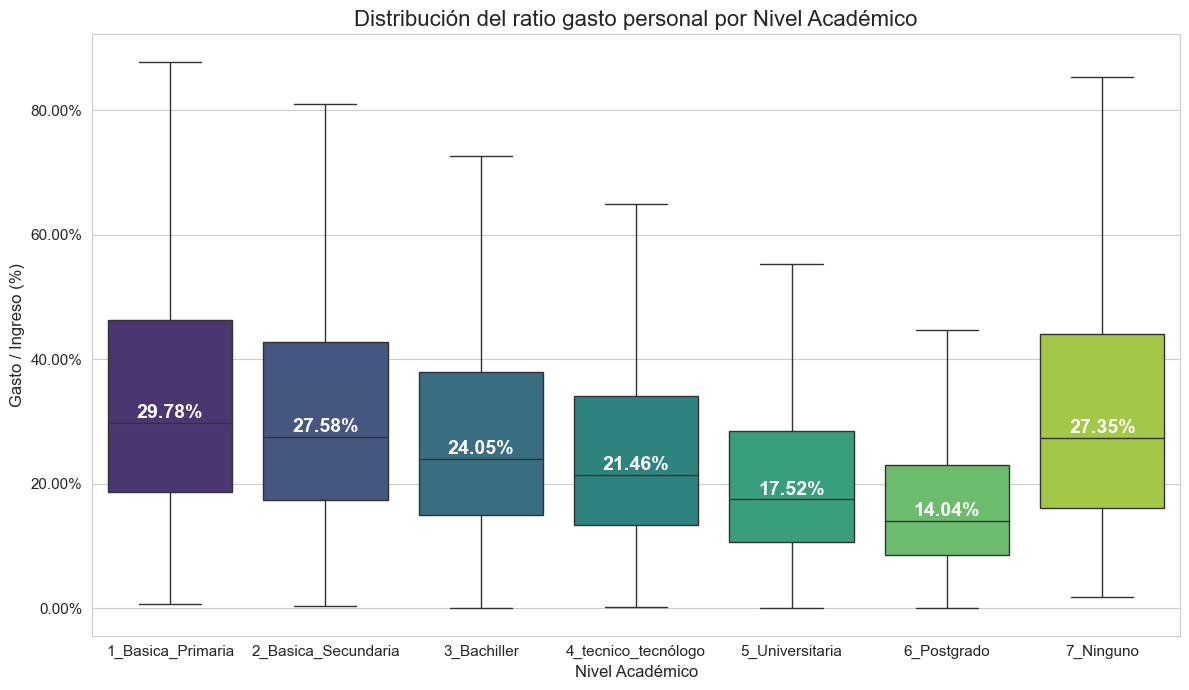

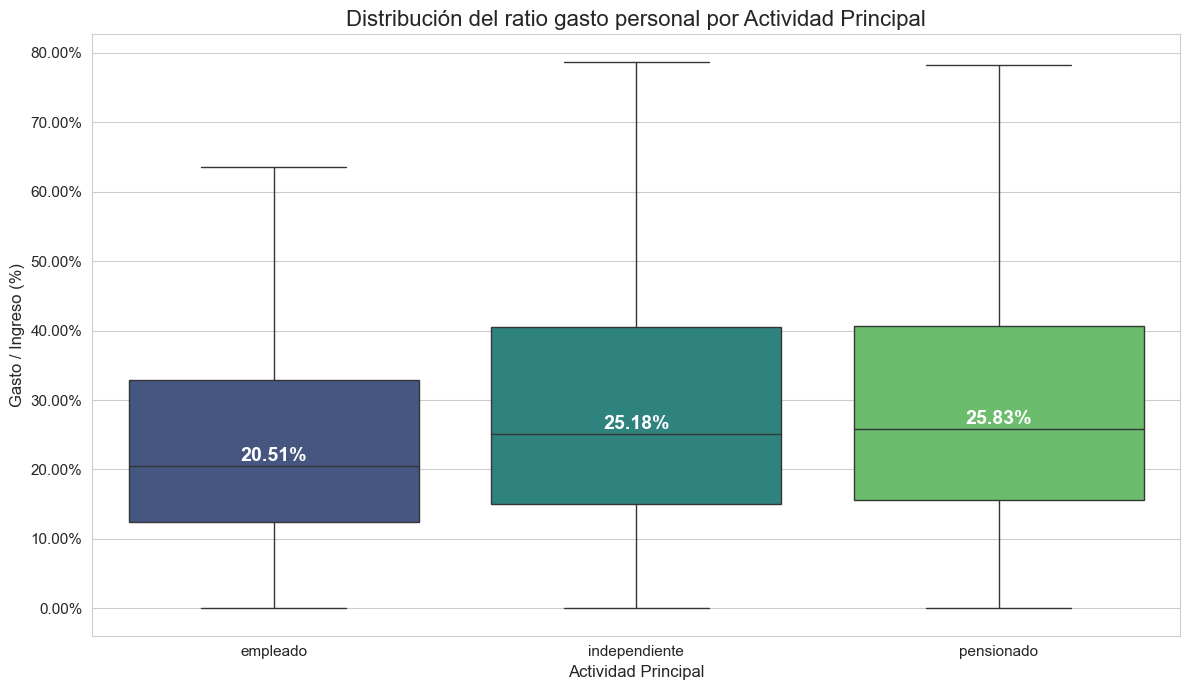

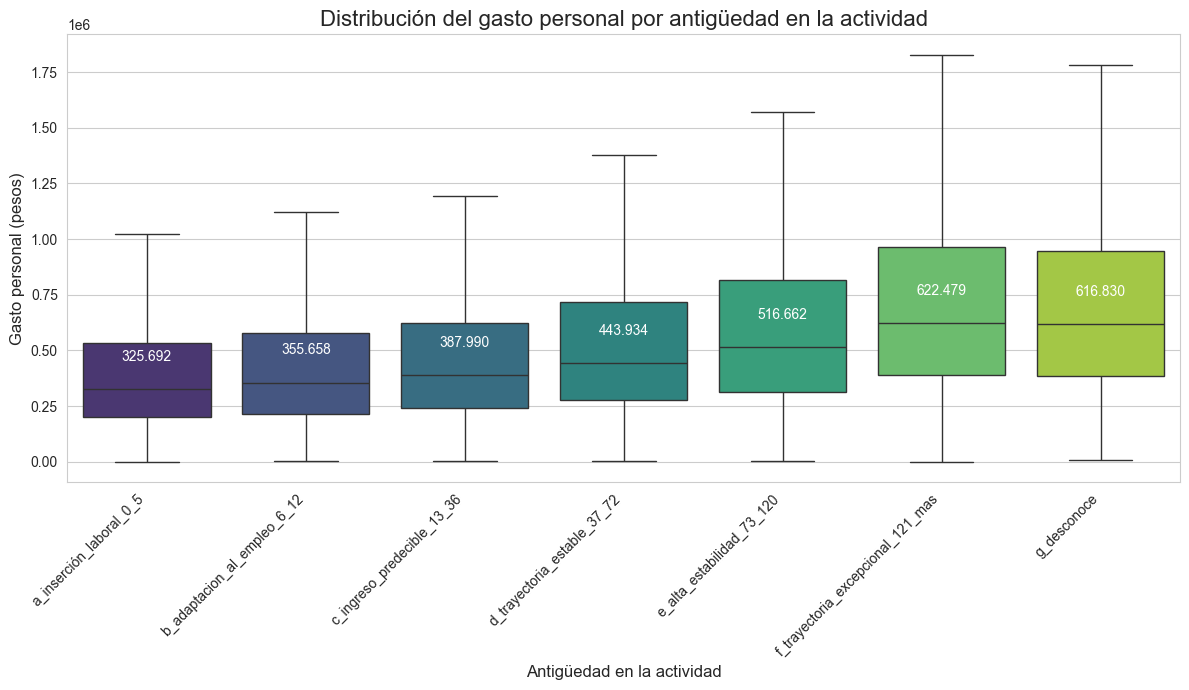

Distribución de individuos por grupo de edad:
Grupo_Edad
18-24     5677
25-34    16196
35-44    13713
45-54    11770
55-64     7530
65+       4890
Name: count, dtype: int64


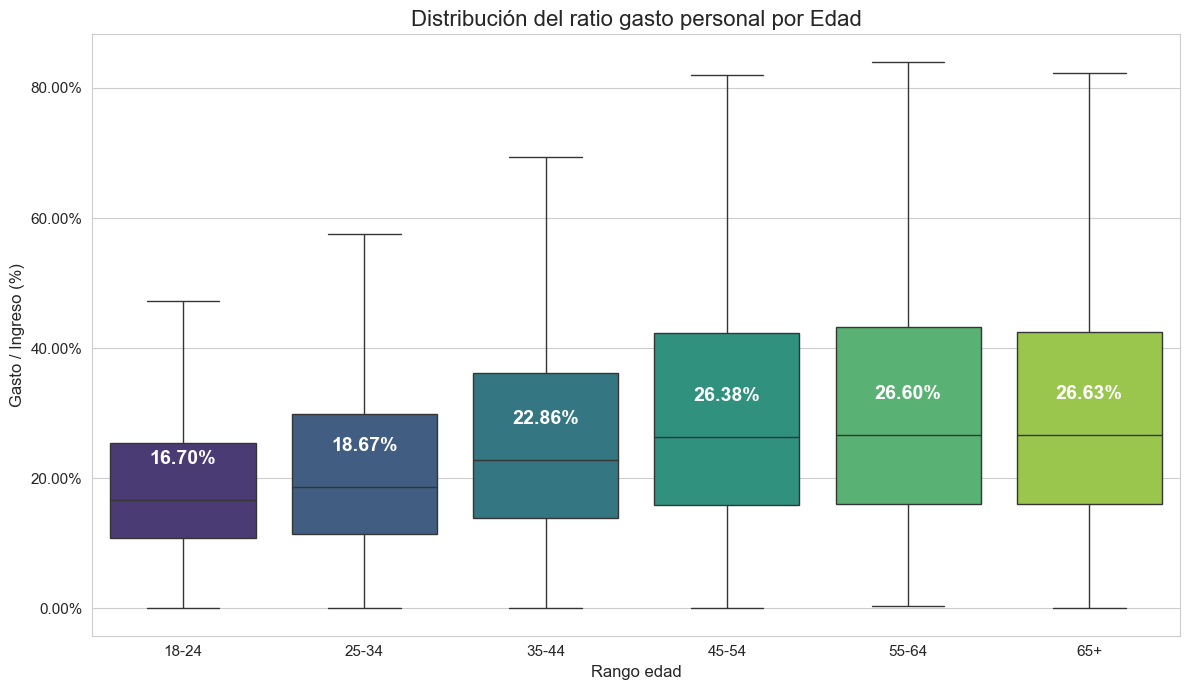

seaborn: 0.13.2
matplotlib: 3.10.5


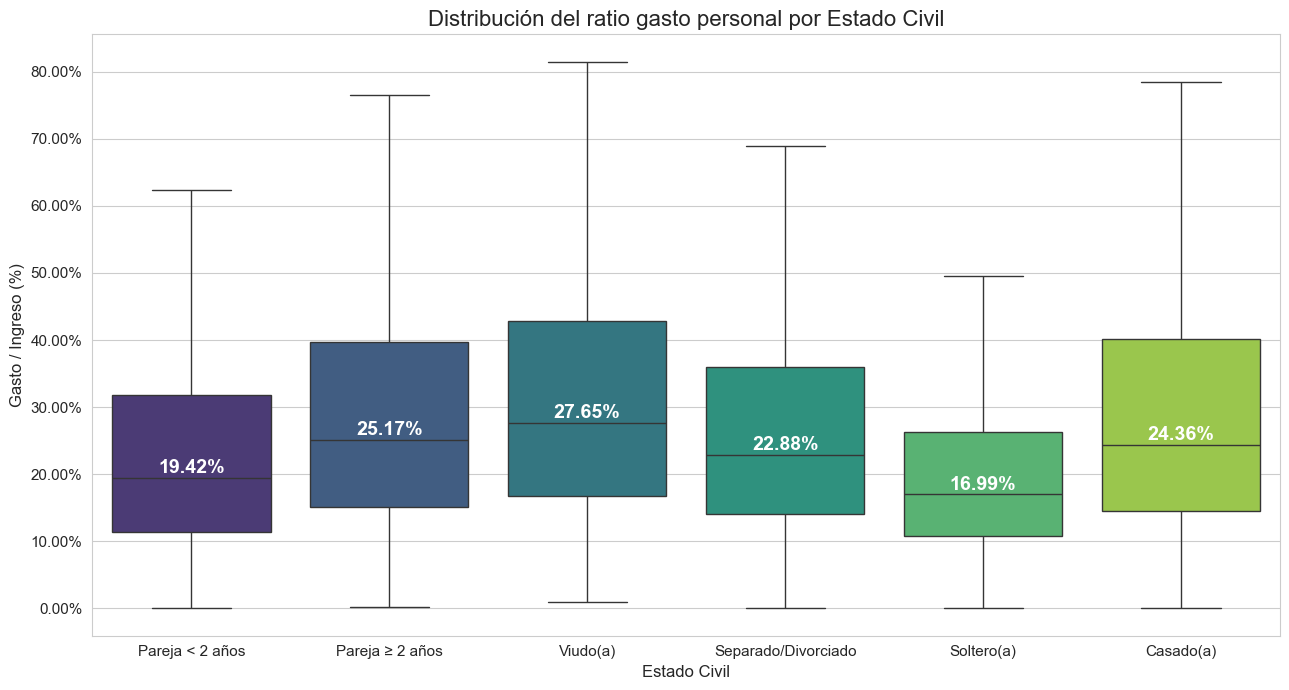

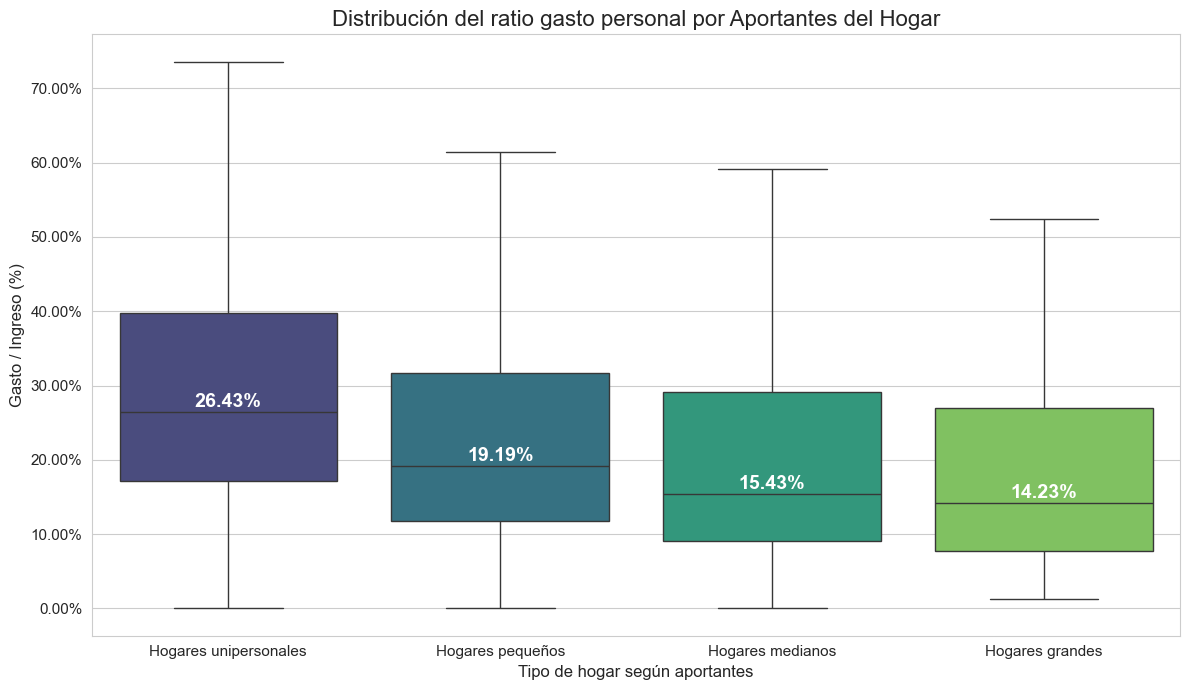

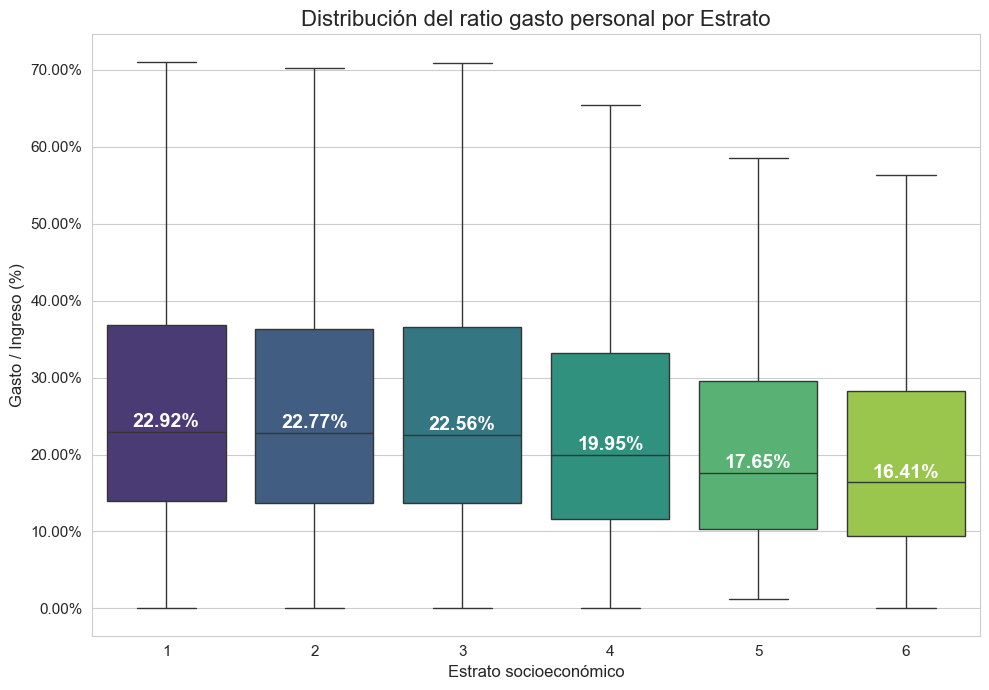

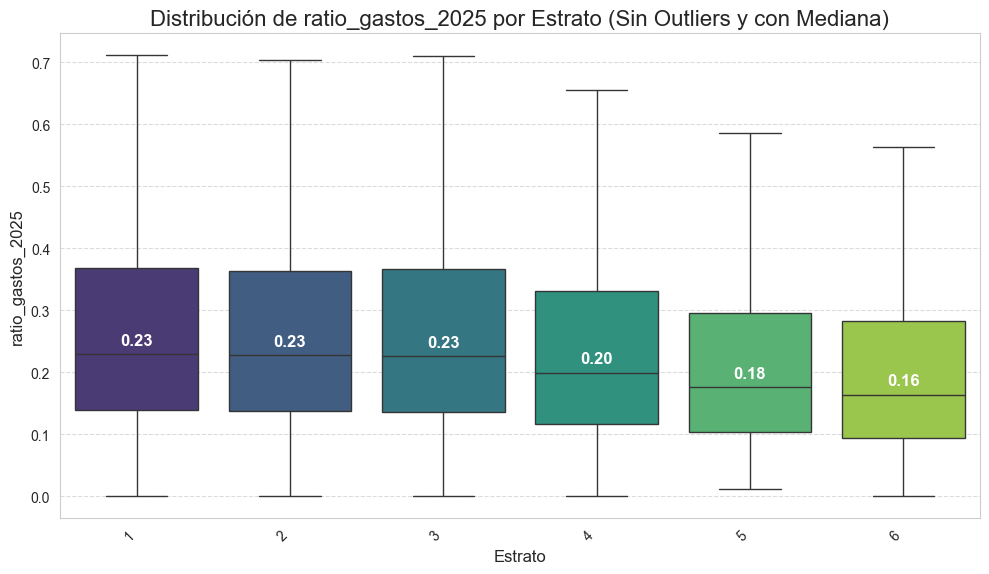

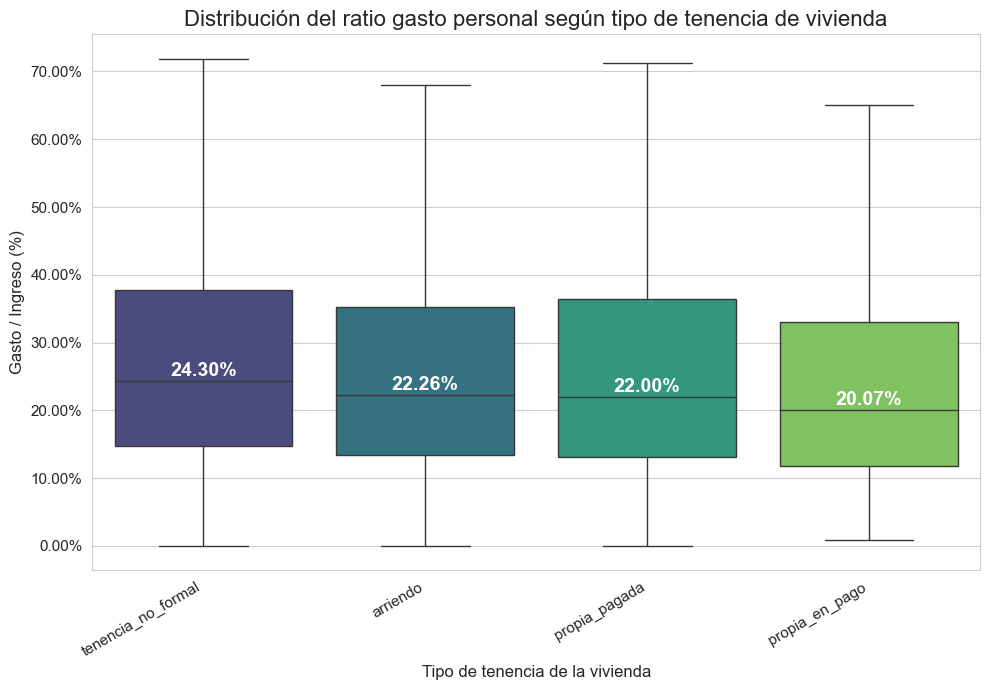

In [5]:
df_temp_=gastos_objetivo_final.copy()

df_temp_.columns

df_temp_['Sexo_'] = df_temp_['Sexo'].replace({1: 'Hombre', 2: 'Mujer'})
df_temp_['EstadoCivil_'] = df_temp_['Estado_Civil'].replace({'1':'No esta casado(a) y vive en pareja hace menos de dos años','2':'No esta casado(a) y vive en pareja hace dos años o más','3':'Esta viudo (a)','4':'Esta separado(a) o divorciado(a)', '5':'Esta soltero (a)','6':'Esta casado (a)'})
df_temp_['NivelAcademico_def'] = df_temp_['NivelAcademico_def'].replace({'3_ Bachiller': '3_Bachiller'})
df_temp_['ClaseVivienda_'] = df_temp_['Clase_Vivienda'].replace({1: 'Casa', 2: 'Apartamento', 3: 'Cuarto (s) en inquilinato', 4: 'Cuarto (s) en otro tipo de estructura', 5: 'Vivienda indígena', 6: 'Otra vivienda (carpa, vagón, embarcación, cueva, refugio natural, etc.)'})
df_temp_['TipoVivienda_'] = df_temp_['Tipo_Vivienda'].replace({1: 'Propia, totalmente pagada', 2: 'Propia, la están pagando', 3: 'En arriendo o subarriendo', 4: 'En usufructo', 5: 'Posesión sin titulo (Ocupante de hecho) ó propiedad colectiva', 6: 'Otra'})

df_temp_a = df_temp_[[
    'DIRECTORIO_x', 'Id_Person', 'Edad', 'Estrato', 'REGION', 'DOMINIO',
    'PERIODO', 'NivelAcademico_def', 'DESC_DIVISION', 'agrup_seccion',
    'Antigüedad_Actividad', 'ingreso_mensual_total', 'actividad_ppal',
    'Aportantes_Hogar', 'F01', 'F02', 'F03', 'F04',
    'F05', 'F06', 'F07', 'F08', 'F09', 'F10', 'F11', 'F12', 'GastoMes',
    'RatioGastos', 'ingreso_smmlv_', 'F01_2025', 'F02_2025', 'F03_2025',
    'F04_2025', 'F05_2025', 'F06_2025', 'F07_2025', 'F08_2025', 'F09_2025',
    'F10_2025', 'F11_2025', 'F12_2025', 'GASTOS_AL_2025',
    'INGRESOS_AL_2025', 'AÑO', 'SMMLV_2025_EQ', 'log_ingresos_2025',
    'log_gastos_2025', 'log_SMMLV_2025_EQ', 'log_ratio_ingreso',
    'Sexo_', 'EstadoCivil_', 'ClaseVivienda_','TipoVivienda_', 'FEX_C'
]].copy()

df_temp_a['Antigüedad_Actividad'] = (
    pd.to_numeric(df_temp_a['Antigüedad_Actividad'], errors='coerce')
    .astype('Int64')
)

df_temp_a['ratio_gastos_2025'] = (
    df_temp_a['GASTOS_AL_2025'] / df_temp_a['INGRESOS_AL_2025']
)

df_temp_a['INGRESOS_AL_2025'] = (
    df_temp_a['INGRESOS_AL_2025']
    .round(0)
    .astype('Int64')
)

df_temp_a['GASTOS_AL_2025'] = (
    df_temp_a['GASTOS_AL_2025']
    .round(0)
    .astype('Int64')
)

import pandas as pd
pd.options.display.float_format = lambda x: f"{x:.2f}".replace('.', ',')
tabla_educacion = (
    df_temp_a
    .groupby('NivelAcademico_def')
    .agg(
        n_obs=('INGRESOS_AL_2025', 'count'),
        ingreso_media=('INGRESOS_AL_2025', 'mean'),
        ingreso_mediana=('INGRESOS_AL_2025', 'median'),
        gasto_media=('GASTOS_AL_2025', 'mean'),
        gasto_mediana=('GASTOS_AL_2025', 'median'),
        ratio_medio=('ratio_gastos_2025', 'mean'),
        ratio_mediana=('ratio_gastos_2025', 'median')
    )
    .reset_index()
)


# Asegurar ratios como float (normalmente ya lo son)
cols_ratio = ['ratio_medio', 'ratio_mediana']
tabla_educacion[cols_ratio] = tabla_educacion[cols_ratio].astype(float)

df_temp_a.columns

df_temp_a['nivel_educ_agrupado'] = df_temp_a['NivelAcademico_def'].astype(str)

# Reglas de agrupación
df_temp_a.loc[
    df_temp_a['NivelAcademico_def'].isin([
        '1_Basica_Primaria',
        '7_Ninguno'
    ]),
    'nivel_educ_agrupado'
] = 'a_Bajo'

df_temp_a.loc[
    df_temp_a['NivelAcademico_def'].isin([
        '2_Basica_Secundaria',
        '3_Bachiller'
    ]),
    'nivel_educ_agrupado'
] = 'b_Medio_bajo'

df_temp_a.loc[
    df_temp_a['NivelAcademico_def'].isin([
        '4_tecnico_tecnólogo'
    ]),
    'nivel_educ_agrupado'
] = 'c_Medio_alto'

df_temp_a.loc[
    df_temp_a['NivelAcademico_def'].isin([
        '5_Universitaria',
        '6_Postgrado'
    ]),
    'nivel_educ_agrupado'
] = 'd_Alto'

# Excluir "No informa"
df_temp_a = df_temp_a[df_temp_a['NivelAcademico_def'] != '8_No_Informa']

tabla_educ_agr = (
    df_temp_a
    .groupby('nivel_educ_agrupado')
    .agg(
        n_obs=('INGRESOS_AL_2025', 'count'),
        ingreso_mediana=('INGRESOS_AL_2025', 'median'),
        gasto_mediana=('GASTOS_AL_2025', 'median'),
        ratio_mediana=('ratio_gastos_2025', 'median')
    )
    .reset_index()
)

tabla_educ_agr

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# --------------------------------------------------
# Definir orden alfabético de los niveles
# --------------------------------------------------
orden_alfabetico = sorted(df_temp_a['NivelAcademico_def'].dropna().unique())

# Calcular medianas y reordenarlas alfabéticamente
medianas_gasto = (
    df_temp_a
    .groupby('NivelAcademico_def')['ratio_gastos_2025']
    .median()
    .reindex(orden_alfabetico)
)

sns.set_style("whitegrid")

plt.figure(figsize=(12, 7))

ax = sns.boxplot(
    x='NivelAcademico_def',
    y='ratio_gastos_2025',
    data=df_temp_a,
    palette='viridis',
    showfliers=False,
    order=orden_alfabetico,   # 🔹 orden alfabético
    ax=plt.gca()
)

# Eje Y en porcentaje con 2 decimales
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda y, _: f'{y*100:.2f}%')
)

# Anotar medianas (cerca de la línea)
for i, nivel in enumerate(orden_alfabetico):
    valor = medianas_gasto[nivel]
    ax.text(
        i,
        valor + (valor * 0.005),
        f'{valor*100:.2f}%',
        ha='center',
        va='bottom',
        fontsize=14,
        fontweight='bold',
        color='white'
    )

plt.title('Distribución del ratio gasto personal por Nivel Académico', fontsize=16)
plt.xlabel('Nivel Académico', fontsize=12)
plt.ylabel('Gasto / Ingreso (%)', fontsize=12)

plt.xticks(rotation=0, ha='center', fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# --------------------------------------------------
# Definir orden alfabético de la actividad principal
# --------------------------------------------------
orden_alfabetico = sorted(df_temp_a['actividad_ppal'].dropna().unique())

# Calcular medianas y reordenarlas alfabéticamente
medianas_gasto = (
    df_temp_a
    .groupby('actividad_ppal')['ratio_gastos_2025']
    .median()
    .reindex(orden_alfabetico)
)

sns.set_style("whitegrid")

plt.figure(figsize=(12, 7))

ax = sns.boxplot(
    x='actividad_ppal',
    y='ratio_gastos_2025',
    data=df_temp_a,
    palette='viridis',
    showfliers=False,
    order=orden_alfabetico,   # 🔹 orden alfabético
    ax=plt.gca()
)

# Eje Y en porcentaje con 2 decimales
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda y, _: f'{y*100:.2f}%')
)

# Anotar medianas (cerca de la línea)
for i, actividad in enumerate(orden_alfabetico):
    valor = medianas_gasto[actividad]
    ax.text(
        i,
        valor + (valor * 0.005),
        f'{valor*100:.2f}%',
        ha='center',
        va='bottom',
        fontsize=14,
        fontweight='bold',
        color='white'
    )

plt.title('Distribución del ratio gasto personal por Actividad Principal', fontsize=16)
plt.xlabel('Actividad Principal', fontsize=12)
plt.ylabel('Gasto / Ingreso (%)', fontsize=12)

plt.xticks(rotation=0, ha='center', fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

import plotly.express as px

fig = px.scatter(
    df_temp_a,
    x='log_ingresos_2025',
    y='log_gastos_2025',
    color='actividad_ppal', # Usa 'color' para diferenciar por actividad principal
    opacity=0.3,
    title='Relación ingreso–gasto por actividad principal (Interactivo)',

    labels={
        'log_ingresos_2025': 'log(Ingreso 2025)',
        'log_gastos_2025': 'log(Gasto 2025)',
        'actividad_ppal': 'Actividad Principal'
    }
)

fig.update_layout(showlegend=True) # Asegura que la leyenda sea visible para la interactividad
fig.show()

import pandas as pd
import numpy as np

df_temp_a['Antigüedad_Actividad'] = pd.to_numeric(
    df_temp_a['Antigüedad_Actividad'],
    errors='coerce'
)

# 1️⃣ Convertir Antigüedad_Actividad de object a numérico
df_temp_a['Antigüedad_Actividad'] = pd.to_numeric(
    df_temp_a['Antigüedad_Actividad'],
    errors='coerce'
)

# 2️⃣ Definir condiciones (boolean numpy, sin NA)
condiciones = [
    df_temp_a['Antigüedad_Actividad'].isin([998, 999]).fillna(False).to_numpy(),
    df_temp_a['Antigüedad_Actividad'].between(0, 5).fillna(False).to_numpy(),
    df_temp_a['Antigüedad_Actividad'].between(6, 12).fillna(False).to_numpy(),
    df_temp_a['Antigüedad_Actividad'].between(13, 36).fillna(False).to_numpy(),
    df_temp_a['Antigüedad_Actividad'].between(37, 72).fillna(False).to_numpy(),
    df_temp_a['Antigüedad_Actividad'].between(73, 120).fillna(False).to_numpy(),
    (df_temp_a['Antigüedad_Actividad'] >= 121).fillna(False).to_numpy()
]

# 3️⃣ Valores (labels consistentes)
valores = [
    'g_desconoce',
    'a_inserción_laboral_0_5',
    'b_adaptacion_al_empleo_6_12',
    'c_ingreso_predecible_13_36',
    'd_trayectoria_estable_37_72',
    'e_alta_estabilidad_73_120',
    'f_trayectoria_excepcional_121_mas'
]

# 4️⃣ Crear variable agrupada
df_temp_a['antiguedad_agrup'] = np.select(
    condiciones,
    valores,
    default=None
)

# 5️⃣ Reemplazar NA restantes por 'g_desconoce'
df_temp_a['antiguedad_agrup'] = df_temp_a['antiguedad_agrup'].fillna('g_desconoce')

# 6️⃣ Convertir a categórica ordenada
orden = [
    'a_inserción_laboral_0_5',
    'b_adaptacion_al_empleo_6_12',
    'c_ingreso_predecible_13_36',
    'd_trayectoria_estable_37_72',
    'e_alta_estabilidad_73_120',
    'f_trayectoria_excepcional_121_mas',
    'g_desconoce'
]

df_temp_a['antiguedad_agrup'] = pd.Categorical(
    df_temp_a['antiguedad_agrup'],
    categories=orden,
    ordered=True
)

(
    df_temp_a
    .loc[df_temp_a['antiguedad_agrup'] == 'g_desconoce']
    .groupby('actividad_ppal')
    .agg(n_obs=('actividad_ppal', 'count'))
    .sort_values('n_obs', ascending=False)
)

import seaborn as sns
import matplotlib.pyplot as plt

# Calcular medianas
medianas_gasto = (
    df_temp_a
    .groupby('antiguedad_agrup')['GASTOS_AL_2025']
    .median()
)

sns.set_style("whitegrid")

plt.figure(figsize=(12, 7))

ax = sns.boxplot(
    x='antiguedad_agrup',
    y='GASTOS_AL_2025',
    data=df_temp_a,
    palette='viridis',
    showfliers=False,
    ax=plt.gca()
)

# Anotar las medianas
for i, antiguedad in enumerate(medianas_gasto.index):
    valor = medianas_gasto[antiguedad]
    ax.text(
        i, valor + (df_temp_a['GASTOS_AL_2025'].max() * 0.01), # Ajustar la posición vertical
        f'{valor:,.0f}'.replace(',', 'X').replace('.', ',').replace('X', '.'), # Formato de miles
        ha='center',
        va='bottom',
        fontsize=10,
        color='white'
    )

plt.title('Distribución del gasto personal por antigüedad en la actividad', fontsize=16)
plt.xlabel('Antigüedad en la actividad', fontsize=12)
plt.ylabel('Gasto personal (pesos)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

import pandas as pd

# Define age bins and labels
bins = [18, 25, 35, 45, 55, 65, 100]
labels = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']

# Create 'Grupo_Edad' column
df_temp_a['Grupo_Edad'] = pd.cut(df_temp_a['Edad'], bins=bins, labels=labels, right=False)

# Display value counts of the new column
print("Distribución de individuos por grupo de edad:")
print(df_temp_a['Grupo_Edad'].value_counts().sort_index())

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Calcular medianas
medianas_gasto = (
    df_temp_a
    .groupby('Grupo_Edad')['ratio_gastos_2025']
    .median()
)

sns.set_style("whitegrid")

plt.figure(figsize=(12, 7))

ax = sns.boxplot(
    x='Grupo_Edad',
    y='ratio_gastos_2025',
    data=df_temp_a,
    palette='viridis',
    showfliers=False,
    ax=plt.gca()
)

# Eje Y en porcentaje con 2 decimales
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda y, _: f'{y*100:.2f}%')
)

# Anotar medianas (más grandes y con 2 decimales)
for i, antiguedad in enumerate(medianas_gasto.index):
    valor = medianas_gasto[antiguedad]
    ax.text(
        i,
        valor + (df_temp_a['ratio_gastos_2025'].max() * 0.01),
        f'{valor*100:.2f}%',
        ha='center',
        va='bottom',
        fontsize=14,      # 🔹 más grande
        fontweight='bold',
        color='white'
    )

plt.title('Distribución del ratio gasto personal por Edad', fontsize=16)
plt.xlabel('Rango edad', fontsize=12)
plt.ylabel('Gasto / Ingreso (%)', fontsize=12)

plt.xticks(rotation=0, ha='center', fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

import seaborn as sns
import matplotlib

print("seaborn:", sns.__version__)
print("matplotlib:", matplotlib.__version__)

df_temp_a.columns

df_temp_a['EstadoCivil_'].unique()

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# --------------------------------------------------
# Homologación de etiquetas (más cortas)
# --------------------------------------------------
estado_civil_map = {
    'No esta casado(a) y vive en pareja hace menos de dos años': 'Pareja < 2 años',
    'No esta casado(a) y vive en pareja hace dos años o más': 'Pareja ≥ 2 años',
    'Esta viudo (a)': 'Viudo(a)',
    'Esta separado(a) o divorciado(a)': 'Separado/Divorciado',
    'Esta soltero (a)': 'Soltero(a)',
    'Esta casado (a)': 'Casado(a)'
}

# Crear variable homologada
df_temp_a['EstadoCivil_hom'] = df_temp_a['EstadoCivil_'].map(estado_civil_map)

# Orden explícito según tu codificación a–f
estado_civil_labels = [
    'Pareja < 2 años',
    'Pareja ≥ 2 años',
    'Viudo(a)',
    'Separado/Divorciado',
    'Soltero(a)',
    'Casado(a)'
]

# Calcular medianas respetando el orden
medianas_gasto = (
    df_temp_a
    .groupby('EstadoCivil_hom')['ratio_gastos_2025']
    .median()
    .reindex(estado_civil_labels)
)

sns.set_style("whitegrid")

plt.figure(figsize=(13, 7))

ax = sns.boxplot(
    x='EstadoCivil_hom',
    y='ratio_gastos_2025',
    data=df_temp_a,
    palette='viridis',
    showfliers=False,
    order=estado_civil_labels,
    ax=plt.gca()
)

# Eje Y en porcentaje con 2 decimales
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda y, _: f'{y*100:.2f}%')
)

# Anotar medianas cerca de la línea
for i, estado in enumerate(estado_civil_labels):
    valor = medianas_gasto[estado]
    ax.text(
        i,
        valor + (valor * 0.005),
        f'{valor*100:.2f}%',
        ha='center',
        va='bottom',
        fontsize=14,
        fontweight='bold',
        color='white'
    )

plt.title('Distribución del ratio gasto personal por Estado Civil', fontsize=16)
plt.xlabel('Estado Civil', fontsize=12)
plt.ylabel('Gasto / Ingreso (%)', fontsize=12)

plt.xticks(rotation=0, ha='center', fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# --------------------------------------------------
# Agrupación y homologación de Aportantes_Hogar
# --------------------------------------------------
bins_aportantes = [1, 2, 3, 5, df_temp_a['Aportantes_Hogar'].max() + 1]
labels_aportantes = [
    'Hogares unipersonales',  # 1 aportante
    'Hogares pequeños',       # 2 aportantes
    'Hogares medianos',       # 3-4 aportantes
    'Hogares grandes'         # 5 o más aportantes
]

df_temp_a['Grupo_Aportantes'] = pd.cut(
    df_temp_a['Aportantes_Hogar'],
    bins=bins_aportantes,
    labels=labels_aportantes,
    right=False,
    include_lowest=True
)

# --------------------------------------------------
# Calcular medianas respetando el orden definido
# --------------------------------------------------
medianas_gasto = (
    df_temp_a
    .groupby('Grupo_Aportantes')['ratio_gastos_2025']
    .median()
    .reindex(labels_aportantes)
)

sns.set_style("whitegrid")

plt.figure(figsize=(12, 7))

ax = sns.boxplot(
    x='Grupo_Aportantes',
    y='ratio_gastos_2025',
    data=df_temp_a,
    palette='viridis',
    showfliers=False,
    order=labels_aportantes,   # 🔹 orden conceptual
    ax=plt.gca()
)

# Eje Y en porcentaje con 2 decimales
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda y, _: f'{y*100:.2f}%')
)

# Anotar medianas (cerca de la línea)
for i, grupo in enumerate(labels_aportantes):
    valor = medianas_gasto[grupo]
    ax.text(
        i,
        valor + (valor * 0.005),
        f'{valor*100:.2f}%',
        ha='center',
        va='bottom',
        fontsize=14,
        fontweight='bold',
        color='white'
    )

plt.title('Distribución del ratio gasto personal por Aportantes del Hogar', fontsize=16)
plt.xlabel('Tipo de hogar según aportantes', fontsize=12)
plt.ylabel('Gasto / Ingreso (%)', fontsize=12)

plt.xticks(rotation=0, ha='center', fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# --------------------------------------------------
# Reasignación directa de Estrato (según tu lógica)
# --------------------------------------------------
def reasignar_estrato_directo(estrato_valor):
    if pd.isna(estrato_valor) or str(estrato_valor).strip() == '':
        return 2  # Asignar 2 a valores vacíos
    elif estrato_valor == 0 or str(estrato_valor) == '0' or estrato_valor == 9 or str(estrato_valor) == '9':
        return 1  # Asignar 1 a 0 y 9
    else:
        try:
            return int(estrato_valor)
        except ValueError:
            return estrato_valor

# Aplicar reasignación
df_temp_a['Estrato'] = df_temp_a['Estrato'].apply(reasignar_estrato_directo)

# --------------------------------------------------
# Definir orden de estratos (ascendente)
# --------------------------------------------------
estrato_labels = sorted(df_temp_a['Estrato'].dropna().unique())

# Calcular medianas respetando el orden
medianas_gasto = (
    df_temp_a
    .groupby('Estrato')['ratio_gastos_2025']
    .median()
    .reindex(estrato_labels)
)

sns.set_style("whitegrid")

plt.figure(figsize=(10, 7))

ax = sns.boxplot(
    x='Estrato',
    y='ratio_gastos_2025',
    data=df_temp_a,
    palette='viridis',
    showfliers=False,
    order=estrato_labels,
    ax=plt.gca()
)

# Eje Y en porcentaje con 2 decimales
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda y, _: f'{y*100:.2f}%')
)

# Anotar medianas (cerca de la línea)
for i, estrato in enumerate(estrato_labels):
    valor = medianas_gasto[estrato]
    ax.text(
        i,
        valor + (valor * 0.005),
        f'{valor*100:.2f}%',
        ha='center',
        va='bottom',
        fontsize=14,
        fontweight='bold',
        color='white'
    )

plt.title('Distribución del ratio gasto personal por Estrato', fontsize=16)
plt.xlabel('Estrato socioeconómico', fontsize=12)
plt.ylabel('Gasto / Ingreso (%)', fontsize=12)

plt.xticks(rotation=0, ha='center', fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define labels for Estrato_Reasignado to ensure consistent order
estrato_reasignado_labels = sorted(df_temp_a['Estrato'].unique()) # Sort for logical order

# Apply Seaborn style as requested
sns.set_style("whitegrid")

plt.figure(figsize=(10, 6)) # Adjust figure size for Estrato

# Use Seaborn for the boxplot with specified palette and hidden outliers
ax = sns.boxplot(
    x='Estrato',
    y='ratio_gastos_2025',
    data=df_temp_a,
    palette='viridis', # Apply specified palette
    showfliers=False,  # Hide outliers as requested
    order=estrato_reasignado_labels # Ensure correct order of categories
)

# Calculate medians (explicitly setting observed=False for categorical groupby to suppress FutureWarning)
medians = df_temp_a.groupby('Estrato', observed=False)['ratio_gastos_2025'].median()

# Loop through each box and add median annotation with specified formatting
for i, group in enumerate(estrato_reasignado_labels): # Use 'estrato_reasignado_labels' to iterate through ordered groups
    if group in medians.index: # Check if median exists for the group
        median_val = medians[group]
        ax.text(
            i, median_val + 0.01, # Place just above the median line
            f'{median_val:.2f}',
            ha='center',
            va='bottom',
            fontsize=12,
            color='white',
            weight='semibold'
        )

plt.title('Distribución de ratio_gastos_2025 por Estrato (Sin Outliers y con Mediana)', fontsize=16) # Title with specific fontsize
plt.suptitle('') # Suppress automatic suptitle
plt.xlabel('Estrato', fontsize=12) # X-label with specific fontsize
plt.ylabel('ratio_gastos_2025', fontsize=12) # Y-label with specific fontsize

plt.xticks(rotation=45, ha='right', fontsize=10) # Rotate x-tick labels and set fontsize
plt.yticks(fontsize=10) # Set y-tick fontsize
plt.grid(axis='y', linestyle='--', alpha=0.7) # Keep grid
plt.tight_layout() # Adjust layout
plt.show()

# 1. Dominios metropolitanos principales
dominio_metro_principal = [
    'BOGOTÁ',
    'MEDELLÍN Y A.M.',
    'CALI',
    'BARRANQUILLA'
]

# 2. Dominios metropolitanos regionales
dominio_metro_regional = [
    'BUCARAMANGA Y A.M.',
    'PEREIRA Y A.M.',
    'MANIZALEZ Y A.M.',
    'CÚCUTA Y A.M.'
]

# 3. Ciudades intermedias
dominio_intermedias = [
    'CARTAGENA', 'SANTA MARTA', 'IBAGUÉ', 'NEIVA',
    'VILLAVICENCIO', 'MONTERÍA', 'VALLEDUPAR',
    'SINCELEJO', 'TUNJA'
]

# 4. Periferia urbana / satélites
dominio_periferia = [
    'SOLEDAD', 'YUMBO', 'RIONEGRO', 'BARRANCABERMEJA'
]

def agrupar_dominio(dominio):
    if dominio in dominio_metro_principal:
        return 'a_Metro_principal'
    elif dominio in dominio_metro_regional:
        return 'b_Metro_regional'
    elif dominio in dominio_intermedias:
        return 'c_Ciudad_intermedia'
    elif dominio in dominio_periferia:
        return 'd_Periferia_urbana'
    else:
        return 'e_Resto'

df_temp_a['dominio_agrup'] = df_temp_a['DOMINIO'].apply(agrupar_dominio)

df_temp_a['dominio_agrup'].value_counts(normalize=True).round(3)

import numpy as np

df_temp_a['tipo_vivienda_agrup'] = np.select(
    [
        df_temp_a['TipoVivienda_'] == 'Propia, totalmente pagada',
        df_temp_a['TipoVivienda_'] == 'Propia, la están pagando',
        df_temp_a['TipoVivienda_'] == 'En arriendo o subarriendo',
        df_temp_a['TipoVivienda_'].isin([
            'En usufructo',
            'Posesión sin titulo (Ocupante de hecho) ó prop...',
            'Otra'
        ])
    ],
    [
        'propia_pagada',
        'propia_en_pago',
        'arriendo',
        'tenencia_no_formal'
    ],
    default='otros'
)

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# --------------------------------------------------
# Definir orden lógico de tipo de vivienda agrupado
# --------------------------------------------------
tipo_vivienda_labels = [
    'tenencia_no_formal',
    'arriendo',
    'propia_pagada',
    'propia_en_pago'
]

# Calcular medianas respetando el orden
medianas_gasto = (
    df_temp_a
    .groupby('tipo_vivienda_agrup')['ratio_gastos_2025']
    .median()
    .reindex(tipo_vivienda_labels)
)

sns.set_style("whitegrid")

plt.figure(figsize=(10, 7))

ax = sns.boxplot(
    x='tipo_vivienda_agrup',
    y='ratio_gastos_2025',
    data=df_temp_a,
    palette='viridis',
    showfliers=False,
    order=tipo_vivienda_labels,
    ax=plt.gca()
)

# --------------------------------------------------
# Eje Y en porcentaje con 2 decimales
# --------------------------------------------------
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda y, _: f'{y*100:.2f}%')
)

# --------------------------------------------------
# Anotar medianas
# --------------------------------------------------
for i, grupo in enumerate(tipo_vivienda_labels):
    valor = medianas_gasto[grupo]
    if pd.notna(valor):
        ax.text(
            i,
            valor + (valor * 0.005),
            f'{valor*100:.2f}%',
            ha='center',
            va='bottom',
            fontsize=14,
            fontweight='bold',
            color='white'
        )

# --------------------------------------------------
# Títulos y etiquetas
# --------------------------------------------------
plt.title('Distribución del ratio gasto personal según tipo de tenencia de vivienda', fontsize=16)
plt.xlabel('Tipo de tenencia de la vivienda', fontsize=12)
plt.ylabel('Gasto / Ingreso (%)', fontsize=12)

plt.xticks(rotation=30, ha='right', fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()


def estadisticos_ponderados(df, var, peso='FEX_C'):
    """Calcula media y mediana ponderadas."""
    w = pd.to_numeric(
        df[peso].astype(str).str.replace(',', '.', regex=False),
        errors='coerce'
    ).fillna(1.0)
    
    x = pd.to_numeric(df[var], errors='coerce')
    mask = x.notna() & w.notna()
    x, w = x[mask].values, w[mask].values
    
    # Media ponderada
    media_w = np.average(x, weights=w)
    
    # Mediana ponderada
    idx = np.argsort(x)
    x_s, w_s = x[idx], w[idx]
    cumw = w_s.cumsum() / w_s.sum()
    mediana_w = x_s[(cumw >= 0.5).argmax()]
    
    return round(media_w, 0), round(mediana_w, 0)




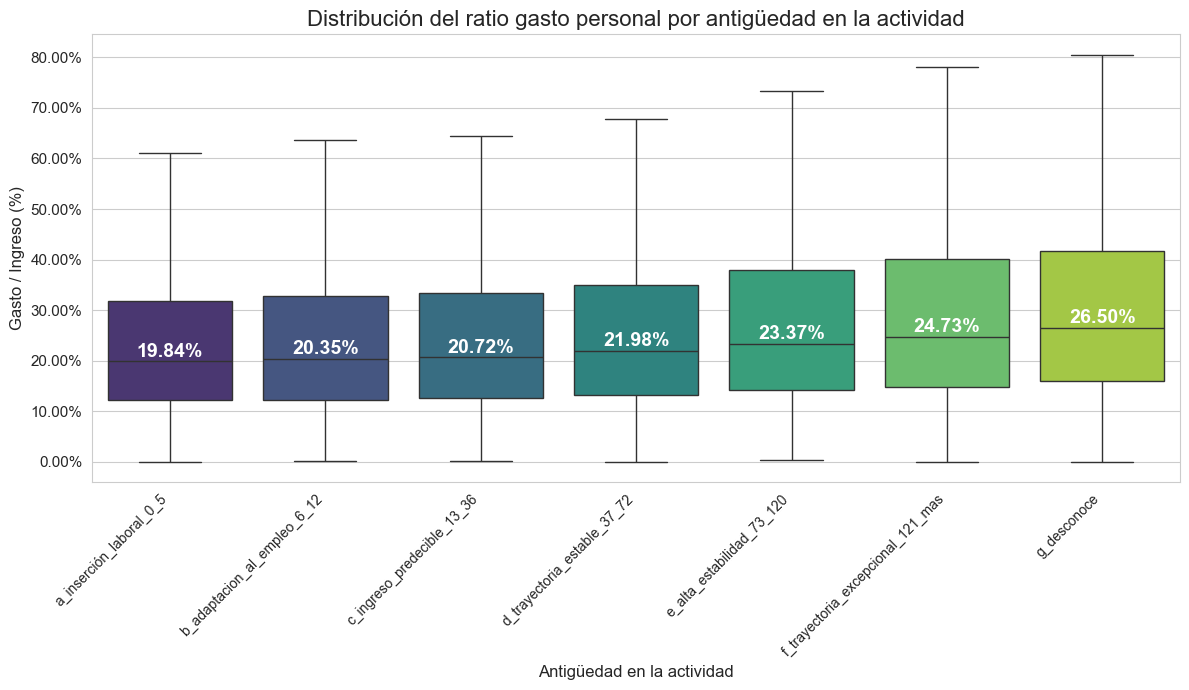

In [6]:
# Calcular medianas del ratio
medianas_gasto = (
    df_temp_a
    .groupby('antiguedad_agrup')['ratio_gastos_2025']
    .median()
)

sns.set_style("whitegrid")

plt.figure(figsize=(12, 7))

ax = sns.boxplot(
    x='antiguedad_agrup',
    y='ratio_gastos_2025',          # 🔹 ratio en lugar de gasto absoluto
    data=df_temp_a,
    palette='viridis',
    showfliers=False,
    ax=plt.gca()
)

# Eje Y en porcentaje con 2 decimales
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda y, _: f'{y*100:.2f}%')
)

# Anotar medianas
for i, antiguedad in enumerate(medianas_gasto.index):
    valor = medianas_gasto[antiguedad]
    ax.text(
        i,
        valor + (valor * 0.005),    # 🔹 offset proporcional al ratio
        f'{valor*100:.2f}%',        # 🔹 formato porcentaje con 2 decimales
        ha='center',
        va='bottom',
        fontsize=14,
        fontweight='bold',
        color='white'
    )

plt.title('Distribución del ratio gasto personal por antigüedad en la actividad', fontsize=16)
plt.xlabel('Antigüedad en la actividad', fontsize=12)
plt.ylabel('Gasto / Ingreso (%)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

### DF para modelar


In [7]:
#dataframe para modelar
print(df_temp_a.shape)
df_temp_a.columns

#crea la variable pensionado como flag debido a que la antiguedad en la actividad los que dicen g_desconoce son pensionados

df_temp_a['flag_pensionado'] = np.where(
    df_temp_a['actividad_ppal'] == 'pensionado',
    'es_pensionado',
    'no_es_pensionado'

)

df_temp_a.columns


(59776, 62)


Index(['DIRECTORIO_x', 'Id_Person', 'Edad', 'Estrato', 'REGION', 'DOMINIO',
       'PERIODO', 'NivelAcademico_def', 'DESC_DIVISION', 'agrup_seccion',
       'Antigüedad_Actividad', 'ingreso_mensual_total', 'actividad_ppal',
       'Aportantes_Hogar', 'F01', 'F02', 'F03', 'F04', 'F05', 'F06', 'F07',
       'F08', 'F09', 'F10', 'F11', 'F12', 'GastoMes', 'RatioGastos',
       'ingreso_smmlv_', 'F01_2025', 'F02_2025', 'F03_2025', 'F04_2025',
       'F05_2025', 'F06_2025', 'F07_2025', 'F08_2025', 'F09_2025', 'F10_2025',
       'F11_2025', 'F12_2025', 'GASTOS_AL_2025', 'INGRESOS_AL_2025', 'AÑO',
       'SMMLV_2025_EQ', 'log_ingresos_2025', 'log_gastos_2025',
       'log_SMMLV_2025_EQ', 'log_ratio_ingreso', 'Sexo_', 'EstadoCivil_',
       'ClaseVivienda_', 'TipoVivienda_', 'FEX_C', 'ratio_gastos_2025',
       'nivel_educ_agrupado', 'antiguedad_agrup', 'Grupo_Edad',
       'EstadoCivil_hom', 'Grupo_Aportantes', 'dominio_agrup',
       'tipo_vivienda_agrup', 'flag_pensionado'],
      dtype='obj

## Validación poblacional: estadísticos ponderados por FEX_C

Los estadísticos anteriores corresponden a la muestra observada.
La siguiente tabla agrega las estimaciones ponderadas por FEX_C
para cada variable, permitiendo comparar la distribución muestral
frente a la población expandida. Las diferencias entre columnas
evidencian el efecto del diseño muestral y justifican el uso del
factor de expansión en todas las fases del análisis.

In [8]:
# ============================================================
# ANÁLISIS DESCRIPTIVO PONDERADO POR FEX_C
# Compara estadísticos muestrales vs. poblacionales
# ============================================================
import pandas as pd
import numpy as np

def estadisticos_ponderados(df, var, peso='FEX_C'):
    """Calcula media y mediana ponderadas por FEX_C."""
    w = pd.to_numeric(
        df[peso].astype(str).str.replace(',', '.', regex=False),
        errors='coerce'
    ).fillna(1.0)
    x = pd.to_numeric(df[var], errors='coerce')
    mask = x.notna() & w.notna()
    x, w = x[mask].values, w[mask].values
    media_w = np.average(x, weights=w)
    idx = np.argsort(x)
    x_s, w_s = x[idx], w[idx]
    cumw = w_s.cumsum() / w_s.sum()
    mediana_w = x_s[(cumw >= 0.5).argmax()]
    return round(media_w, 0), round(mediana_w, 0)


def tabla_ponderada(df, grupo_var, ing_var, gto_var, peso='FEX_C'):
    """
    Genera tabla con estadísticos muestrales y poblacionales
    para una variable de agrupación dada.
    """
    resultados = []
    for nombre, grupo in df.groupby(grupo_var, observed=True):
        media_w_ing, med_w_ing = estadisticos_ponderados(grupo, ing_var, peso)
        media_w_gto, med_w_gto = estadisticos_ponderados(grupo, gto_var, peso)
        resultados.append({
            'Grupo'                      : nombre,
            'n (muestra)'                : len(grupo),
            'Pob. expandida (∑FEX_C)'    : round(
                pd.to_numeric(
                    grupo[peso].astype(str).str.replace(',', '.', regex=False),
                    errors='coerce'
                ).sum(), 0),
            'Ingreso Mediana (muestra)'  : round(
                pd.to_numeric(grupo[ing_var], errors='coerce').median(), 0),
            'Ingreso Mediana (pob.)'     : med_w_ing,
            'Gasto Mediana (muestra)'    : round(
                pd.to_numeric(grupo[gto_var], errors='coerce').median(), 0),
            'Gasto Mediana (pob.)'       : med_w_gto,
        })
    return pd.DataFrame(resultados)


# ── Variables a usar ───────────────────────────────────────
ING = 'INGRESOS_AL_2025'
GTO = 'GASTOS_AL_2025'
df  = df_temp_a   # dataframe con todas las variables agrupadas ya creadas

# ── Tabla 1: Nivel educativo agrupado ─────────────────────
print("=" * 70)
print("TABLA: Nivel educativo agrupado")
print("=" * 70)
t1 = tabla_ponderada(df, 'nivel_educ_agrupado', ING, GTO)
display(t1)

# ── Tabla 2: Actividad principal ──────────────────────────
print("=" * 70)
print("TABLA: Actividad principal")
print("=" * 70)
t2 = tabla_ponderada(df, 'actividad_ppal', ING, GTO)
display(t2)

# ── Tabla 3: Antigüedad agrupada ──────────────────────────
print("=" * 70)
print("TABLA: Antigüedad en la actividad")
print("=" * 70)
t3 = tabla_ponderada(df, 'antiguedad_agrup', ING, GTO)
display(t3)

# ── Tabla 4: Grupo de edad ────────────────────────────────
print("=" * 70)
print("TABLA: Grupo de edad")
print("=" * 70)
t4 = tabla_ponderada(df, 'Grupo_Edad', ING, GTO)
display(t4)

# ── Tabla 5: Sexo ─────────────────────────────────────────
print("=" * 70)
print("TABLA: Sexo")
print("=" * 70)
t5 = tabla_ponderada(df, 'Sexo_', ING, GTO)
display(t5)

# ── Tabla 6: Estado civil ─────────────────────────────────
print("=" * 70)
print("TABLA: Estado civil")
print("=" * 70)
t6 = tabla_ponderada(df, 'EstadoCivil_hom', ING, GTO)
display(t6)

# ── Tabla 7: Aportantes del hogar ─────────────────────────
print("=" * 70)
print("TABLA: Aportantes del hogar")
print("=" * 70)
t7 = tabla_ponderada(df, 'Grupo_Aportantes', ING, GTO)
display(t7)

# ── Tabla 8: Estrato ──────────────────────────────────────
print("=" * 70)
print("TABLA: Estrato socioeconómico")
print("=" * 70)
t8 = tabla_ponderada(df, 'Estrato', ING, GTO)
display(t8)

# ── Tabla 9: Dominio agrupado ─────────────────────────────
print("=" * 70)
print("TABLA: Dominio geográfico agrupado")
print("=" * 70)
t9 = tabla_ponderada(df, 'dominio_agrup', ING, GTO)
display(t9)

# ── Tabla 10: Tipo de vivienda agrupado ───────────────────
print("=" * 70)
print("TABLA: Tipo de tenencia de vivienda")
print("=" * 70)
t10 = tabla_ponderada(df, 'tipo_vivienda_agrup', ING, GTO)
display(t10)

TABLA: Nivel educativo agrupado


,Grupo,n (muestra),Pob. expandida (∑FEX_C),Ingreso Mediana (muestra),Ingreso Mediana (pob.),Gasto Mediana (muestra),Gasto Mediana (pob.)
0,a_Bajo,7156,"961498,00","1427168,00",1429442,"485116,00",498951
1,b_Medio_bajo,25770,"3535397,00","1479131,00",1485412,"426308,00",429125
2,c_Medio_alto,9598,"1380220,00","1651170,00",1764080,"412332,00",424358
3,d_Alto,17252,"2275981,00","2966833,00",3268972,"517768,00",566741


TABLA: Actividad principal


,Grupo,n (muestra),Pob. expandida (∑FEX_C),Ingreso Mediana (muestra),Ingreso Mediana (pob.),Gasto Mediana (muestra),Gasto Mediana (pob.)
0,empleado,36591,"5285638,00","1622531,00",1648240,"401120,00",413380
1,independiente,16485,"2049940,00","1760324,00",1905923,"520730,00",559854
2,pensionado,6700,"817518,00","2223576,00",2229246,"623600,00",667756


TABLA: Antigüedad en la actividad


...

,Grupo,n (muestra),Pob. expandida (∑FEX_C),Ingreso Mediana (muestra),Ingreso Mediana (pob.),Gasto Mediana (muestra),Gasto Mediana (pob.)
0,1,12276,"1160460,00","1429442,00",1427168,"376705,00",372902
1,2,21756,"2689309,00","1588269,00",1529276,"415630,00",407572
2,3,17850,"3098133,00","1974024,00",1965603,"498622,00",501192
3,4,5169,"737003,00","3109983,00",3292142,"630800,00",666700
4,5,1808,"306354,00","4285425,00",4800885,"773254,00",835125
5,6,917,"161838,00","5767744,00",6492496,"1025182,00",1088041


TABLA: Dominio geográfico agrupado


,Grupo,n (muestra),Pob. expandida (∑FEX_C),Ingreso Mediana (muestra),Ingreso Mediana (pob.),Gasto Mediana (muestra),Gasto Mediana (pob.)
0,a_Metro_principal,13352,"5521951,00","1712115,00",1785436,"464009,00",469418
1,b_Metro_regional,8785,"889487,00","1611643,00",1639527,"473534,00",487899
2,c_Ciudad_intermedia,16973,"1022201,00","1729258,00",1657041,"464957,00",459687
3,d_Periferia_urbana,7063,"249014,00","1606565,00",1543521,"446567,00",455475
4,e_Resto,13603,"470443,00","1902890,00",1803480,"425476,00",430900


TABLA: Tipo de tenencia de vivienda


,Grupo,n (muestra),Pob. expandida (∑FEX_C),Ingreso Mediana (muestra),Ingreso Mediana (pob.),Gasto Mediana (muestra),Gasto Mediana (pob.)
0,arriendo,23486,"3679814,00","1626202,00",1644572,"430140,00",432108
1,otros,1141,"110630,00","1447668,00",1460812,"402953,00",402349
2,propia_en_pago,2386,"440138,00","2292748,00",2378613,"524113,00",531525
3,propia_pagada,27834,"3317072,00","1902890,00",1947749,"475913,00",512085
4,tenencia_no_formal,4929,"605444,00","1560830,00",1582965,"438970,00",449457


## **Análisis descriptivo ponderado por FEX_C — corrección para revisión del jurado**

Esta sección complementa el análisis descriptivo presentado anteriormente para responder a la observación del jurado sobre la incorporación del factor de expansión calibrado **FEX_C** en todas las dimensiones del análisis. Por cada variable categórica de interés se construye una tabla con dos planos paralelos —muestral y poblacional expandido— que permite (i) reportar estadísticos representativos de la población colombiana de aportantes del hogar, (ii) hacer transparente el sesgo del muestreo de la ENPH respecto a la población, y (iii) cerrar con una **Tabla 19** que sintetiza las divergencias muestra-vs-expandido por variable.

El detalle metodológico se documenta en la Sección 5.4 del manuscrito y la lógica corresponde al script `script_descriptivos_ponderados.py` integrado a continuación.

### Helpers — estadística ponderada por FEX_C

In [9]:
# ============================================================
# Helpers — media, mediana, percentiles y IQR ponderados
# ============================================================
import numpy as np
import pandas as pd


def media_ponderada(x, w):
    """Media ponderada estándar: Σ(x·w) / Σw."""
    x = pd.to_numeric(x, errors="coerce").astype(float)
    w = pd.to_numeric(w, errors="coerce").astype(float)
    valid = ~(np.isnan(x) | np.isnan(w))
    if valid.sum() == 0:
        return np.nan
    return np.average(x[valid], weights=w[valid])


def percentil_ponderado(x, w, q):
    """Percentil ponderado: ordena por x y acumula los pesos hasta alcanzar q."""
    x = pd.to_numeric(x, errors="coerce").astype(float).values
    w = pd.to_numeric(w, errors="coerce").astype(float).values
    valid = ~(np.isnan(x) | np.isnan(w))
    x, w = x[valid], w[valid]
    if len(x) == 0:
        return np.nan
    idx = np.argsort(x)
    x_s, w_s = x[idx], w[idx]
    cw = np.cumsum(w_s) / w_s.sum()
    i = np.searchsorted(cw, q)
    return x_s[min(i, len(x_s) - 1)]


def mediana_ponderada(x, w):
    return percentil_ponderado(x, w, 0.5)


def iqr_ponderado(x, w):
    return percentil_ponderado(x, w, 0.75) - percentil_ponderado(x, w, 0.25)

### Función resumen por categoría — variables monetarias

In [10]:
# ============================================================
# Resumen por categoría con planos muestral y expandido
# ============================================================
def resumen_categoria(df, col_cat, col_fex="FEX_C",
                      col_ingreso="INGRESOS_AL_2025",
                      col_gasto="GASTOS_AL_2025"):
    """
    Para cada categoría de col_cat devuelve N muestra/N expandido,
    porcentajes en cada plano, medianas e ingresos/gastos en plano
    muestral y expandido, diferencia en puntos porcentuales.
    """
    df = df.copy()
    df[col_fex] = pd.to_numeric(df[col_fex], errors="coerce").astype(float)
    n_total = len(df)
    n_exp_total = df[col_fex].sum()
    out = []
    for cat, grupo in df.groupby(col_cat):
        n_mue = len(grupo)
        n_exp = grupo[col_fex].sum()
        out.append({
            "Categoría": cat,
            "N muestra": n_mue,
            "N expandido": round(n_exp),
            "% muestra": round(n_mue / n_total * 100, 2),
            "% expandido": round(n_exp / n_exp_total * 100, 2),
            "Δ pp (exp - mue)": round(n_exp / n_exp_total * 100 - n_mue / n_total * 100, 2),
            "Ingreso media muestra": round(grupo[col_ingreso].mean()),
            "Ingreso media expandida": round(media_ponderada(grupo[col_ingreso], grupo[col_fex])),
            "Ingreso mediana muestra": round(grupo[col_ingreso].median()),
            "Ingreso mediana expandida": round(mediana_ponderada(grupo[col_ingreso], grupo[col_fex])),
            "Gasto mediana muestra": round(grupo[col_gasto].median()),
            "Gasto mediana expandida": round(mediana_ponderada(grupo[col_gasto], grupo[col_fex])),
        })
    return pd.DataFrame(out)

### Función resumen por categoría — variables territoriales (en logs)

In [11]:
def resumen_categoria_log(df, col_cat, col_fex="FEX_C",
                          col_log_gasto="log_gastos_2025",
                          col_log_ingreso="log_ingresos_2025"):
    """Versión en logs para variables territoriales (Región, Dominio)."""
    df = df.copy()
    df[col_fex] = pd.to_numeric(df[col_fex], errors="coerce").astype(float)
    n_total = len(df); n_exp_total = df[col_fex].sum()
    out = []
    for cat, grupo in df.groupby(col_cat):
        n_mue = len(grupo); n_exp = grupo[col_fex].sum()
        out.append({
            "Categoría": cat,
            "N muestra": n_mue,
            "N expandido": round(n_exp),
            "% muestra": round(n_mue / n_total * 100, 2),
            "% expandido": round(n_exp / n_exp_total * 100, 2),
            "Δ pp": round(n_exp / n_exp_total * 100 - n_mue / n_total * 100, 2),
            "Mediana log gasto muestra": round(grupo[col_log_gasto].median(), 2),
            "Mediana log gasto expandida": round(mediana_ponderada(grupo[col_log_gasto], grupo[col_fex]), 2),
            "IQR log gasto muestra": round(grupo[col_log_gasto].quantile(0.75) - grupo[col_log_gasto].quantile(0.25), 2),
            "IQR log gasto expandida": round(iqr_ponderado(grupo[col_log_gasto], grupo[col_fex]), 2),
        })
    return pd.DataFrame(out)

### Total expandido de la población objetivo

La suma del FEX_C sobre la población de aportantes del hogar reproduce el total estimado en Colombia para el período de referencia. Este número se cita en la apertura de la Sección 5.4 del manuscrito.

In [12]:
# Busca el script en BASE_PATH (raíz del proyecto) para compatibilidad
# con notebooks ejecutados desde subcarpeta o desde la raíz.
_script_path = BASE_PATH / "script_descriptivos_ponderados.py"
if not _script_path.exists():
    # fallback: mismo directorio de trabajo (ej. si está en notebooks/)
    _script_path = Path("script_descriptivos_ponderados.py")
if not _script_path.exists():
    raise FileNotFoundError(
        f"No se encontró script_descriptivos_ponderados.py. "
        f"Verifica que esté en: {BASE_PATH} o en el directorio de trabajo."
    )
exec(open(_script_path).read())
print(f"✅ {_script_path.name} ejecutado desde: {_script_path.parent}")

TABLAS PONDERADAS POR FEX_C — Sección 5.4 de la tesis

Total expandido de la población objetivo (aportantes): 8,153,097

--- nivel_academico (columna: nivel_educ_agrupado) ---
   Categoría  N muestra  N expandido  % muestra  % expandido  Δ pp (exp - mue)  Ingreso media muestra  Ingreso media expandida  Ingreso mediana muestra  Ingreso mediana expandida  Gasto mediana muestra  Gasto mediana expandida
      a_Bajo       7156    961498,00      11,97        11,79             -0,18             1818450,00               1828237,00               1427168,00                 1429442,00              485116,00                498951,00
b_Medio_bajo      25770   3535397,00      43,11        43,36              0,25             1961313,00               2022455,00               1479131,00                 1485412,00              426308,00                429125,00
c_Medio_alto       9598   1380220,00      16,06        16,93              0,87             2216259,00               2291070,00               16

In [13]:
# Busca el script en BASE_PATH (raíz del proyecto) para compatibilidad
# con notebooks ejecutados desde subcarpeta o desde la raíz.
_script_path = BASE_PATH / "script_seleccion_variables.py"
if not _script_path.exists():
    # fallback: mismo directorio de trabajo (ej. si está en notebooks/)
    _script_path = Path("script_seleccion_variables.py")
if not _script_path.exists():
    raise FileNotFoundError(
        f"No se encontró script_seleccion_variables.py. "
        f"Verifica que esté en: {BASE_PATH} o en el directorio de trabajo."
    )
exec(open(_script_path).read())
print(f"✅ {_script_path.name} ejecutado desde: {_script_path.parent}")

SELECCIÓN DE VARIABLES — Sección 5.5 del manuscrito

N muestral total:  59,776
N expandido total: 8,153,097

----------------------------------------------------------------------
VARIABLES NUMÉRICAS
----------------------------------------------------------------------

log_ingresos_2025:
  Spearman ρ ponderado : 0.3947
  Pearson ρ ponderado  : 0.4310
  p-valor (Spearman)   : 0
  Decisión             : Incluir

Edad:
  Spearman ρ ponderado : 0.4006
  Pearson ρ ponderado  : 0.3743
  p-valor (Spearman)   : 0
  Decisión             : Incluir

--- VIF (multicolinealidad entre numéricas) ---
  log_ingresos_2025         VIF =     1.05  [OK]
  Edad                      VIF =     1.05  [OK]

----------------------------------------------------------------------
VARIABLES CATEGÓRICAS
----------------------------------------------------------------------

Sexo_:
  Kruskal-Wallis p-valor : 0
  Eta-cuadrado ponderado : 0.0298
  N min muestral / cat   : 24260
  % min poblacional / cat: 40.31%
  Re

In [14]:
# Busca el script en BASE_PATH (raíz del proyecto) para compatibilidad
# con notebooks ejecutados desde subcarpeta o desde la raíz.
_script_path = BASE_PATH / "script_correlaciones_y_boxplots.py"
if not _script_path.exists():
    # fallback: mismo directorio de trabajo (ej. si está en notebooks/)
    _script_path = Path("script_correlaciones_y_boxplots.py")
if not _script_path.exists():
    raise FileNotFoundError(
        f"No se encontró script_correlaciones_y_boxplots.py. "
        f"Verifica que esté en: {BASE_PATH} o en el directorio de trabajo."
    )
exec(open(_script_path).read())
print(f"✅ {_script_path.name} ejecutado desde: {_script_path.parent}")

1. MATRIZ DE CORRELACIONES PONDERADA POR FEX_C

Variables numéricas analizadas: ['log_ingresos_2025', 'log_gastos_2025', 'Edad', 'log_ratio_ingreso']

--- Matriz Pearson ponderada ---
                   log_ingresos_2025  log_gastos_2025  Edad  log_ratio_ingreso
log_ingresos_2025               1,00             0,43  0,19               1,00
log_gastos_2025                 0,43             1,00  0,37               0,43
Edad                            0,19             0,37  1,00               0,19
log_ratio_ingreso               1,00             0,43  0,19               1,00

--- Matriz Spearman ponderada ---
                   log_ingresos_2025  log_gastos_2025  Edad  log_ratio_ingreso
log_ingresos_2025               1,00             0,40  0,17               1,00
log_gastos_2025                 0,40             1,00  0,40               0,39
Edad                            0,17             0,40  1,00               0,17
log_ratio_ingreso               1,00             0,39  0,17           

In [15]:
# Total expandido de la población objetivo
total_exp = pd.to_numeric(df_temp_a["FEX_C"], errors="coerce").astype(float).sum()
print(f"Total expandido de la población objetivo (aportantes): {total_exp:,.0f}")

Total expandido de la población objetivo (aportantes): 0


### Generación de tablas ponderadas por variable

Las siguientes celdas generan, para cada variable categórica analizada en la Sección 5.4 del manuscrito, una tabla con planos muestral y expandido. Cada tabla queda disponible como un DataFrame en memoria y se exporta también a `tablas_ponderadas.xlsx` (una hoja por variable) para facilitar su pegado en el documento corregido.

In [16]:
# Mapa variable → columna en df_temp_a (se ajusta automáticamente si la columna no existe)
_candidatos_columnas = {
    "nivel_academico":   ["nivel_educ_agrupado", "nivel_academico_agrupado", "nivel_academico"],
    "actividad_economica": ["actividad_ppal", "actividad_principal"],
    "rango_edad":        ["rango_edad", "Rango_Edad", "edad_grupo"],
    "sexo":              ["Sexo_", "Sexo", "sexo"],
    "estado_civil":      ["EstadoCivil_", "Estado_Civil", "estado_civil"],
    "estrato":           ["Estrato"],
    "aportantes_hogar":  ["Grupo_Aportantes", "grupo_aportantes", "Aportantes_Hogar"],
    "region":            ["REGION", "region"],
    "tipo_vivienda":     ["tipo_vivienda_agrup", "Tipo_Vivienda_Agrup", "tipo_vivienda"],
}

variables_a_analizar = {}
for nombre, candidatos in _candidatos_columnas.items():
    encontrada = next((c for c in candidatos if c in df_temp_a.columns), None)
    if encontrada:
        variables_a_analizar[nombre] = encontrada
    else:
        print(f"  ! {nombre}: ninguna de las columnas candidatas existe en df_temp_a; se omite")

print("\nVariables a analizar (nombre lógico → columna):")
for k, v in variables_a_analizar.items():
    print(f"  {k:<22} → {v}")

  ! rango_edad: ninguna de las columnas candidatas existe en df_temp_a; se omite

Variables a analizar (nombre lógico → columna):
  nivel_academico        → nivel_educ_agrupado
  actividad_economica    → actividad_ppal
  sexo                   → Sexo_
  estado_civil           → EstadoCivil_
  estrato                → Estrato
  aportantes_hogar       → Grupo_Aportantes
  region                 → REGION
  tipo_vivienda          → tipo_vivienda_agrup


In [17]:
# ============================================================
# Ejecutar el resumen para cada variable y guardar en Excel
# ============================================================
from pathlib import Path

tablas_por_variable = {}
resumen_divergencias_filas = []

for nombre, col in variables_a_analizar.items():
    print(f"\n--- {nombre} (columna: {col}) ---")
    if nombre == "region":
        tabla = resumen_categoria_log(df_temp_a, col)
    else:
        tabla = resumen_categoria(df_temp_a, col)
    tablas_por_variable[nombre] = tabla
    print(tabla.to_string(index=False))

    # Capturar la categoría con mayor divergencia para la Tabla 19
    col_delta = "Δ pp" if "Δ pp" in tabla.columns else "Δ pp (exp - mue)"
    if col_delta in tabla.columns and len(tabla) > 0:
        idx_max = tabla[col_delta].abs().idxmax()
        resumen_divergencias_filas.append({
            "Variable": nombre,
            "Categoría con mayor divergencia": tabla.loc[idx_max, "Categoría"],
            "% muestra": tabla.loc[idx_max, "% muestra"],
            "% expandido": tabla.loc[idx_max, "% expandido"],
            "Diferencia (pp)": tabla.loc[idx_max, col_delta],
        })

df_resumen_divergencias = (
    pd.DataFrame(resumen_divergencias_filas)
    .sort_values("Diferencia (pp)", key=lambda s: s.abs(), ascending=False)
    .reset_index(drop=True)
)


--- nivel_academico (columna: nivel_educ_agrupado) ---
   Categoría  N muestra  N expandido  % muestra  % expandido  Δ pp (exp - mue)  Ingreso media muestra  Ingreso media expandida  Ingreso mediana muestra  Ingreso mediana expandida  Gasto mediana muestra  Gasto mediana expandida
      a_Bajo       7156    961498,00      11,97        11,79             -0,18             1818450,00               1828237,00               1427168,00                 1429442,00              485116,00                498951,00
b_Medio_bajo      25770   3535397,00      43,11        43,36              0,25             1961313,00               2022455,00               1479131,00                 1485412,00              426308,00                429125,00
c_Medio_alto       9598   1380220,00      16,06        16,93              0,87             2216259,00               2291070,00               1651170,00                 1764080,00              412332,00                424358,00
      d_Alto      17252   2275981,00

### Tabla 19 — Resumen de divergencias muestra-vs-expandido

Cierra el análisis descriptivo. Cada fila identifica la categoría donde el FEX_C produjo el mayor ajuste respecto a la composición muestral. Las variables al inicio del listado (mayor divergencia) son aquellas en las que el muestreo del DANE discrimina más entre subgrupos para garantizar precisión inferencial.

In [18]:
print("=" * 70)
print("TABLA 19 — Resumen de divergencias muestra-vs-expandido")
print("=" * 70)
print(df_resumen_divergencias.to_string(index=False))

TABLA 19 — Resumen de divergencias muestra-vs-expandido
           Variable Categoría con mayor divergencia  % muestra  % expandido  Diferencia (pp)
             region                          BOGOTÁ       7,58        37,32            29,74
            estrato                               3      29,86        38,00             8,14
      tipo_vivienda                   propia_pagada      46,56        40,68            -5,88
   aportantes_hogar           Hogares unipersonales      48,03        43,16            -4,87
actividad_economica                        empleado      61,21        64,83             3,62
       estado_civil                Esta soltero (a)      23,72        26,14             2,41
    nivel_academico                          d_Alto      28,86        27,92            -0,95
               sexo                          Hombre      59,42        59,69             0,28


### Exportación a Excel

Las tablas ponderadas se exportan a `tablas_ponderadas.xlsx` (una hoja por variable + hoja `resumen_divergencias` con la Tabla 19). Los valores deben pegarse en los placeholders `[W:XXX]` del documento `Comprension_datos_corregido.docx`.

In [19]:
# Exportar a Excel — una hoja por variable + hoja de resumen
ruta_excel = Path.cwd() / "tablas_ponderadas.xlsx"

with pd.ExcelWriter(ruta_excel, engine="openpyxl") as writer:
    for nombre, tabla in tablas_por_variable.items():
        tabla.to_excel(writer, sheet_name=nombre[:31], index=False)
    df_resumen_divergencias.to_excel(
        writer, sheet_name="resumen_divergencias", index=False
    )

print(f"\nTablas guardadas en: {ruta_excel}")
print("Una hoja por variable + hoja \"resumen_divergencias\" para la Tabla 19.")
print("\nPróximo paso: copiar los valores desde Excel a los placeholders [W:XXX]")
print("del documento Comprension_datos_corregido.docx.")


Tablas guardadas en: /Users/paolavelandia/01_a_T_E_S_I_S/01_tesis_v4/notebooks/tablas_ponderadas.xlsx
Una hoja por variable + hoja "resumen_divergencias" para la Tabla 19.

Próximo paso: copiar los valores desde Excel a los placeholders [W:XXX]
del documento Comprension_datos_corregido.docx.


---
## 💾 Persistencia — Exportación NB03
Guarda el dataset analítico final `df_temp_a` para `04_modelado.ipynb`.

In [20]:

# ============================================================
# EXPORTACIÓN DE DATOS — FIN NB03
# Guarda el dataset analítico final para NB04
# ============================================================
ruta_analitico = PERSIST_DIR / "nb03_df_temp_a.parquet"
df_temp_a_save = df_temp_a.copy()
for col in df_temp_a_save.select_dtypes(include='category').columns:
    df_temp_a_save[col] = df_temp_a_save[col].astype(str)
df_temp_a_save.to_parquet(ruta_analitico, index=False)

print(f"✅ NB03 → dataset analítico guardado: {df_temp_a.shape}")
print(f"   Ruta: {ruta_analitico}")


✅ NB03 → dataset analítico guardado: (59776, 63)
   Ruta: /Users/paolavelandia/01_a_T_E_S_I_S/01_tesis_v4/02_intermedios/nb03_df_temp_a.parquet
